# Comparative Neutronic Analysis of UN-ThN vs. Traditional UO2 Fuel in An infinite pincell Lattice - Phase 01 : Begining of life

* **Author:** Clément DAROUSSIN
* **Date:** April 11, 2026
* **Project Type:** Self-initiated R&D Project – Advanced Fuel Cycle Study
* **Software:** OpenMC 14.3.0
* **Library:** JEFF-3.3 (Continuous Energy)
* **Sources/references** : 
    * **Geometry :** *Godfrey, A. T. (2014). VERA Core Physics Benchmark Progression Problem Specifications (Revision 4). Oak Ridge National Laboratory, CASL-U-2012-0131-004.*
    * **Fuel composition :** *Ishraq, M. A. R., & Roy, S. (2024). A comparative neutronic analysis of U–Th fuels as potential alternatives to traditional UO2 fuel for enhanced performance and safety in the ACP-100 SMR. Results in Engineering, 21, 101822.*

This study provides a preliminary neutronic assessment of Uranium-Thorium Nitride (UN-ThN) fuel as an alternative to the industry-standard UO2.

## TECHNICAL DATA SHEET : OPENMC CONFIGURATION (PINCELL UO2 - BOL)
### DESIGN & GEOMETRY
*Source : OECD/NEA and U.S. NRC PWR MOX/UO2 Core Transient Benchmark; Kozlowski and Downar; 2003*

| Parameter | Value | Details |
| :--- | :--- | :--- |
| **Cell Type** | Unit Pincell (3D) | 3D Square lattice with axial leakage |
| **Fuel Radius ($r_1$)** | 0.4096 cm | Standard PWR pellet |
| **Clad Outer Radius ($r_3$)** | 0.4750 cm | Zircaloy-4 cladding |
| **Pitch** | 1.26 cm | Lattice spacing (X, Y axes) |
| **Active Fuel Height** | 420.00 cm | EPR2 standard active length |
| **Axial Reflectors** | 20.00 cm (x2) | Light water zones at top and bottom |
| **Total Model Height** | 460.00 cm | Cumulative Z-axis length |
| **Boundary Conditions** | Reflective / Vacuum | **Reflective** on X/Y (infinite lattice)<br>**Vacuum** on Z ext. (real leakage) |

### PHYSICS & NUCLEAR DATA
*Source : OpenMC JEFF-3.3 Nuclear Data Library*

| Parameter | Value | Status |
| :--- | :--- | :--- |
| **Nuclear Library** | JEFF-3.3 | HDF5 format |
| **Energy Treatment** | Continuous | High-fidelity resolution |
| **Fuel Temperature** | 900K (then 1200K for doppler coef) | // |
| **Other Temperature** | 600K | // |
| **Thermal Scattering** | `c_H_in_H2O` | S(α, β) applied |
| **Transport Mode** | K-Eigenvalue | Neutron transport only |

### MONTE CARLO STATISTICS SPECIFICATIONS

| Parameter | Value | Detail / Impact |
| :--- | :--- | :--- |
| **Geometry** | 2D Unit Cell | Infinite lattice (Reflective BC) |
| **Transport Mode** | Monte Carlo | K-eigenvalue (OpenMC) |
| **Particles per Cycle** | 50,000 | / |
| **Active Batches** | 250 | For statistical convergence and variance reduction |
| **Inactive Batches** | 50 | Source stabilization |
| **Total Histories ($N$)** | 12,500,000 | Global precision $\sigma \approx 30$ pcm ($0.03\%$) |

## I - Imports and global parameters

We start by importing OpenMC and defining the standard dimensions for both the reference (UO2) and test (UN-ThN) cases.

In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os

os.system('rm *.h5 *.xml *.out')

0

(Reload data from statepoint files files)

In [2]:
# # Force reload of certified 900K data from disk
# results_spectrum = {}
# results_power = {}
# results_conversion = {}

# for name in ['UO2', 'UN_ThN']:
#     filename = f'statepoint_{name}_900K.h5'
#     with openmc.StatePoint(filename) as sp:
#         # Properly extract the neutron spectrum
#         tally = sp.get_tally(name='flux_spectrum')
#         results_spectrum[name] = tally.mean.flatten()
        
#         # Properly extract the radial power distribution
#         tally_pow = sp.get_tally(name='radial_power')
#         results_power[name] = tally_pow.get_values(scores=['fission']).flatten()
        
#         # Properly extract Conversion Ratio (CR) data
#         results_conversion[name] = sp.get_tally(name='conversion_rates')

# print("Data successfully reloaded from 900K statepoint files.")

## II - Materials definition

This section defines the isotopic compositions and physical densities of the materials within the pin cell. The composition parameters used in this simulation are derived from the literature : $\textit{“Neutronic and thermal-hydraulic analysis of (U-Th)N fuel in a PWR (Table 2)”}$ :

### A. The industry standard : UO2
The reference UO2 fuel is defined with a physical density of **10.422 g/cm³** and a fixed enrichment of **4.95 wt% $^{235}\text{U}$**. This specific value is the practical limit for most existing commercial fabrication facilities (often referred to as "low enriched uranium" or LEU). It represents the maximum reactivity potential available in current Generation III PWRs to optimize fuel cycle length. 

Using this value as a reference for both geometry and materials ensures a consistent baseline that strictly follows the parameters defined in the reference study. Furthermore, this strategy aligns the benchmark with the operational standards of the **EPR2**, which serves as the industrial model for this simulation. This "high enrichment" approach also maximizes the neutronic contrast between the fuels, making it easier to differentiate and analyze the specific performance benefits of the U-Th matrix within a next-generation reactor environment.

### B. Advanced Fuel: UN-ThN (The Alternative)
The uranium-thorium nitride (**UN-ThN**) mixture (80% UN + 20% ThN) is an advanced fuel candidate currently being studied for Generation IV reactors and specialized SMRs. 

Nitride fuels are investigated as alternatives to oxides due to their **higher heavy-metal density and superior thermal conductivity**. These properties allow for higher power densities (enabling more compact reactor cores) and ensure efficient heat removal while maintaining a lower fuel centerline temperature. This significantly increases the safety margin by maintaining a greater **distance to the melting point**.

The use of natural Nitrogen would introduce a significant reactivity penalty due to the $^{14}N(n,p)^{14}C$ reaction, which acts as a strong thermal neutron poison. To ensure optimal neutronic economy, the nitride composition typically assumes enrichment in $^{15}\text{N}$, as natural nitrogen ($^{14}\text{N}$) acts as a strong neutron poison through the (n,p) reaction.

| Fuel material | Density (g/cm³) | U-235 enrichment (wt%) | Heavy metal mass (×10³ kg) |
| :--- | :---: | :---: | :---: |
| **UO2 (Reference)** | 10.422 | 4.95 | 16.21 |
| **UN-ThN (Test)** | 10.792 | 4.95 | 17.37 |

### C. Structural Materials & Gap
While the reference study for fuel compositions uses specific ACP-100 parameters (such as an Oxygen gap), this benchmark adopts **industry-standard structural materials** to ensure results are applicable to broader PWR technology. 

The cladding is modeled as **Zircaloy-4**, a standard nuclear-grade alloy, and the gap is filled with **Helium**. This configuration provides a more conventional environment to evaluate the transition from UO2 to UN-ThN.

In [3]:
# ==============================================================================
# 1. REFERENCE FUEL: UO2
# ==============================================================================
uo2 = openmc.Material(1, "uo2")
uo2.add_element('U', 1.0, enrichment=4.95) 
uo2.add_element('O', 2.0)
uo2.set_density('g/cm3', 10.422)  

# ==============================================================================
# 2. TEST FUEL: UN-ThN
# ==============================================================================
un_thn = openmc.Material(2, "un_thn")

# Atomic Proportions: 80% Uranium / 20% Thorium
# Note: For SMRs like the ACP-100, enrichment is often boosted to 
# compensate for Thorium's high absorption. We maintain 4.95% for 
# a direct benchmark comparison with standard UO2.
un_thn.add_element('U', 0.8, enrichment=4.95) 
un_thn.add_nuclide('Th232', 0.2) 
    
# Nitrogen-15 to avoid neutron absorption issues with Nitrogen-14
un_thn.add_nuclide('N15', 1.0)

# Density value from Table 2 for (UN+ThN) mixture
un_thn.set_density('g/cm3', 10.792)

# ==============================================================================
# 3. STRUCTURAL & MODERATOR
# ==============================================================================
# Zircaloy-4 (Standard nuclear grade alloy)
zircaloy = openmc.Material(3, "zircaloy") # Composition based on weight fractions ('wo') for ASTM standards
zircaloy.add_element('Zr', 0.98115, 'wo')
zircaloy.add_element('Sn', 0.0145, 'wo')
zircaloy.add_element('Fe', 0.0021, 'wo')
zircaloy.add_element('Cr', 0.001, 'wo')
zircaloy.add_element('Hf', 0.0001, 'wo') # Hafnium is a strong absorber, strictly limited
zircaloy.set_density('g/cm3', 6.55)
zircaloy.temperature = 600.0

# gap : helium
helium = openmc.Material(4, "helium")
helium.add_element('He', 1.0)
helium.set_density('g/cm3', 0.00015)
helium.temperature = 600.0

# moderator : light water
water = openmc.Material(5, "h2o")
water.add_nuclide('H1', 2.0)
water.add_element('O', 1.0)
water.set_density('g/cm3', 0.6628) # Density of water at 600 K and 15 MPa (superheated conditions)
water.add_s_alpha_beta('c_H_in_H2O') # S(a,b) is essential for correct thermal neutron scattering in water
water.temperature = 600.0

# Exporting the collection
mats = openmc.Materials([uo2, un_thn, zircaloy, helium, water])
mats.export_to_xml()

## III - Geometry Setup
The geometry is modeled as an infinite pin cell lattice using reflective boundary conditions. 

Dimensions are taken from the **"VERA Core Physics Benchmark Progression Problem Specifications; Godfrey; 2014"** 

The choice of dimensions based on the **WBN1 (Watts Bar Unit 1)** benchmark is justified by the industrial standardization of Pressurized Water Reactors (PWR) like EP2. 

* **Fuel pellet radius ($r_1$):** 0.4096 cm
* **Cladding inner radius ($r_2$):** 0.4180 cm (helium gap)
* **Cladding outer radius ($r_3$):** 0.4750 cm
* **Pin pitch:** 1.26 cm
* **Height:** 420cm

### A. 2D - model

In [4]:
#3D model #########################################################################################
# # Adjustable parameters for the pin cell 
# n_circles = 501 # circular mesh

# fuel_or      = 0.4096   # Pellet Radius
# clad_ir      = 0.4180   # Inner Clad Radius
# clad_or      = 0.4750   # Outer Clad Radius
# pitch        = 1.26     # Rod Pitch

# # Surfaces
# surf_fuel = openmc.ZCylinder(r=fuel_or)
# surf_clad_ir = openmc.ZCylinder(r=clad_ir)
# surf_clad_or = openmc.ZCylinder(r=clad_or)


# # Reflective box for infinite lattice (Pin Cell)
# left   = openmc.XPlane(x0=-pitch/2, boundary_type='reflective')
# right  = openmc.XPlane(x0=pitch/2,  boundary_type='reflective')
# bottom = openmc.YPlane(y0=-pitch/2, boundary_type='reflective')
# top    = openmc.YPlane(y0=pitch/2,  boundary_type='reflective')

# # Regions definitions
# fuel_region = -surf_fuel
# gap_region = +surf_fuel & -surf_clad_ir
# clad_region = +surf_clad_ir & -surf_clad_or
# water_region = +left & -right & +bottom & -top & +surf_clad_or


# # Filling regions
# fuel = openmc.Cell(1, 'fuel')
# fuel.fill = uo2
# fuel.region = fuel_region

# gap = openmc.Cell(2, 'helium gap')
# gap.fill = helium
# gap.region = gap_region

# clad = openmc.Cell(3, 'clad')
# clad.fill = zircaloy
# clad.region = clad_region

# moderator = openmc.Cell(4, 'moderator')
# moderator.fill = water
# moderator.region = water_region


# # Geometry export
# geometry = openmc.Geometry([fuel, gap, clad, moderator])
# geometry.export_to_xml()


### B. 3D - model

In [5]:

# --- PARAMETERS ---
height = 420.0  # Active fuel height for EPR2 (cm)
reflector_thickness = 20.0 # Axial water reflector (cm)

# Existing radial parameters
fuel_or  = 0.4096
clad_ir  = 0.4180
clad_or  = 0.4750
pitch    = 1.26

# --- SURFACES ---
# Radial surfaces (Z-axis cylinders)
surf_fuel = openmc.ZCylinder(r=fuel_or)
surf_clad_ir = openmc.ZCylinder(r=clad_ir)
surf_clad_or = openmc.ZCylinder(r=clad_or)


# Axial bounds
z0 = openmc.ZPlane(z0=-height/2)
z1 = openmc.ZPlane(z0=height/2)
z_bot_ext = openmc.ZPlane(z0=-(height/2 + reflector_thickness), boundary_type='vacuum')
z_top_ext = openmc.ZPlane(z0=(height/2 + reflector_thickness), boundary_type='vacuum')

# Reflective box for infinite lattice (X & Y planes)
left   = openmc.XPlane(x0=-pitch/2, boundary_type='reflective')
right  = openmc.XPlane(x0=pitch/2,  boundary_type='reflective')
bottom = openmc.YPlane(y0=-pitch/2, boundary_type='reflective')
top    = openmc.YPlane(y0=pitch/2,  boundary_type='reflective')

# --- REGIONS ---
# All regions now include the axial bounds (+z_bottom & -z_top)
core_range = +z0 & -z1
refl_range = (+z_bot_ext & -z0) | (+z1 & -z_top_ext)
fuel_region  = -surf_fuel & core_range
gap_region   = +surf_fuel & -surf_clad_ir & core_range
clad_region  = +surf_clad_ir & -surf_clad_or & core_range
water_region = +left & -right & +bottom & -top & +surf_clad_or & core_range

# --- CELLS ---
fuel = openmc.Cell(1, 'fuel')
fuel.fill = uo2
fuel.region = fuel_region

gap = openmc.Cell(2, 'helium gap')
gap.fill = helium
gap.region = gap_region

clad = openmc.Cell(3, 'clad')
clad.fill = zircaloy
clad.region = clad_region

moderator = openmc.Cell(4, 'moderator')
moderator.fill = water
moderator.region = water_region

reflector = openmc.Cell(5, 'axial reflectors')
reflector.fill = water
reflector.region = +left & -right & +bottom & -top & refl_range

# --- GEOMETRY EXPORT ---
geometry = openmc.Geometry([fuel, gap, clad, moderator,reflector])
geometry.export_to_xml()


### C. Plotting the geometry

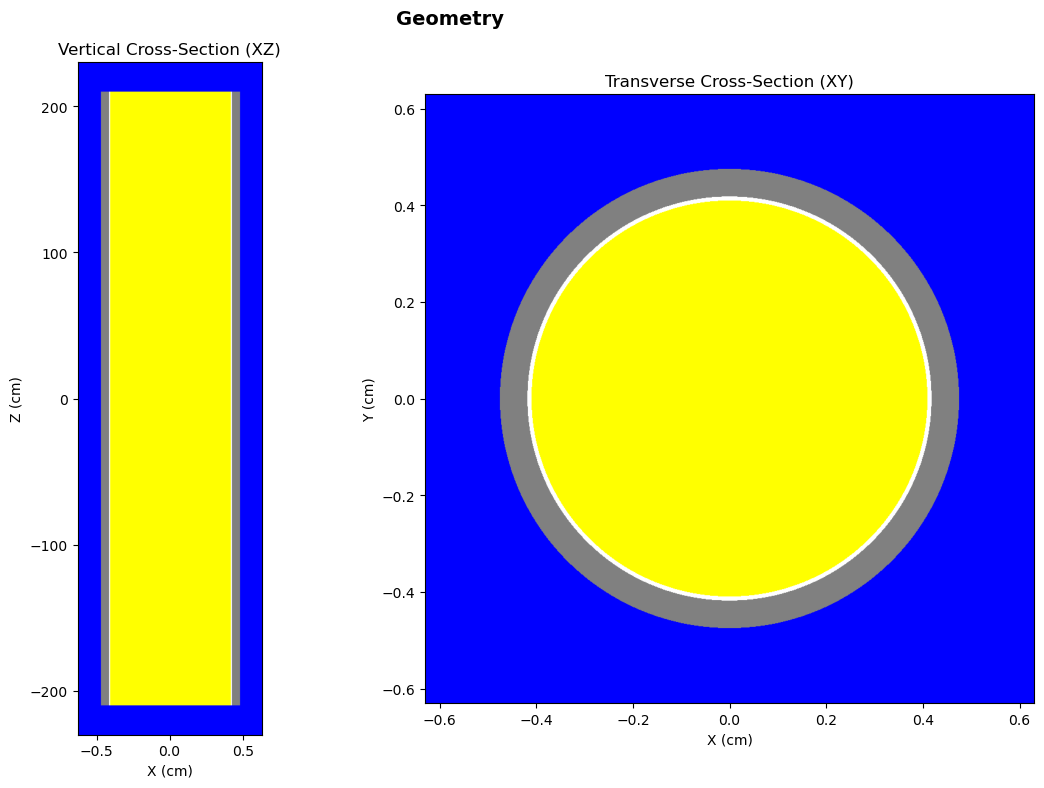

In [6]:
import matplotlib.pyplot as plt

# --- INITIAL CONFIGURATION ---
total_height = 460.0  # 420 cm active fuel + 40 cm reflectors (20 cm x2)

# 1. Create a SINGLE figure cleanly split into 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

# ==========================================
# LEFT: STRETCHED VERTICAL CROSS-SECTION (XZ)
# ==========================================
geometry.plot(
    origin=(0.0, 0.0, 0.0),
    width=(pitch, total_height),
    basis="xz",
    color_by="material",
    pixels=(500, 500),
    colors={uo2: "yellow", zircaloy: "grey", water: "blue", helium: "white"},
    axes=ax1,  # Forces OpenMC to draw inside the left subplot
)
#ax1.set_aspect('auto')  # Stretches the width so the thin pin is clearly visible
ax1.set_aspect(0.01)  # Stretches the width so the thin pin is clearly visible
ax1.set_title("Vertical Cross-Section (XZ)")
ax1.set_xlabel("X (cm)")
ax1.set_ylabel("Z (cm)")


# ==========================================
# RIGHT: TRANSVERSE CROSS-SECTION (XY)
# ==========================================
geometry.plot(
    origin=(0.0, 0.0, 0.0),
    width=(pitch, pitch),
    basis="xy",
    color_by="material",
    pixels=(1000, 1000),
    colors={uo2: "yellow", zircaloy: "grey", water: "blue", helium: "white"},
    axes=ax2,  # Forces OpenMC to draw inside the right subplot
)

ax2.set_title("Transverse Cross-Section (XY)")
ax2.set_xlabel("X (cm)")
ax2.set_ylabel("Y (cm)")


# ==========================================
# FIGURE FINALIZATION AND DISPLAY
# ==========================================
plt.suptitle("Geometry", fontsize=14, fontweight="bold")
plt.tight_layout()

# Save and show the single combined plot (no ghost windows)
plt.savefig("geometry_plots_side_by_side.png", dpi=300)
plt.show()

## IV - Simulation configuration

The **eigenvalue mode** is used to determine the system's $k_{\infty}$ and a uniform spatial source is defined within the fuel region. The use of the `only_fissionable = True` ensures that the initial neutron births are strictly confined to the fuel pellet.

To achieve a statistical precision of approximately $0.03\%$ (~30 pcm), the number of active particles was set at **10,000,000** (calculated as $N = 1/\sigma^2$). This population is distributed over **200** batches (**50,000** each batch). 

For a simple pin-cell geometry, the Shannon Entropy typically stabilizes around the 20th cycle (a 20% safety margin was applied, resulting in **50** inactive batches), giving a total of **250** batches of (**10,000,000 + 50 * 50,000 = 12,500,000** simulated histories).

### A. Setting and Source definition

In [7]:
settings = openmc.Settings()
settings.run_mode = 'eigenvalue'

settings.particles = 50000
settings.batches = 250
settings.inactive = 50

# Critical: Enable temperature interpolation for Doppler effects
settings.temperature = {
    'method': 'interpolation' 
}

# Definition of a cylindrical spatial source (Uniformly distributed within the fuel)
# r: [0, fuel_or], phi: [0, 2pi], z: [-H, H] (here set for a 2D plane)
# lower_left = (-fuel_or, -fuel_or, -1.0)
# upper_right = (fuel_or, fuel_or, 1.0)

#3d model
lower_left = (-fuel_or, -fuel_or, -210.0)
upper_right = (fuel_or, fuel_or, 210.0)
uniform_dist = openmc.stats.Box(lower_left, upper_right, only_fissionable=True) #'only_fissionable=True' force the source to start only in the fuel   

source = openmc.IndependentSource()
source.space = uniform_dist
settings.source = source

settings.export_to_xml()

/home/darou/miniconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


### B. Tally configurations

This preliminary analysis focuses on three key tallies to characterize and validate the unit cell model. 
* **Neutron flux spectrum :** The use of 250 energy groups allows for a fine discretization in lethargy (u), defined as $u = \ln(E_0/E)$. This logarithmic approach is essential to accurately capture the slowing-down process (neutrons lose energy proportionally to their lethargy during each collision).
* **Radial power distribution :** Using a `CylindricalMesh` across the fuel pellet radius to assess the **self-shielding effect**.
* **Conversion ratio :** Reaction rates for radiative capture $(n,\gamma)$, fission, and total absorption are tracked specifically for $^{232}\text{Th}$, $^{238}\text{U}$, and $^{235}\text{U}$. This comprehensive tracking of absorption events (combining both productive fissions and parasitic captures) is essential for an accurate balance of the neutron economy and the subsequent calculation of the **conversion ratio (CR)**. 

*A subsequent 17x17 assembly study will incorporate absorption rates and burnup for a more exhaustive analysis.*

In [8]:
tallies = openmc.Tallies()
n_circles = 251  # Number of radial divisions for the mesh tally

# NEUTRON FLUX SPECTRUM
energies = np.logspace(-5, 7, 5001) 
energy_filter = openmc.EnergyFilter(energies)
tally_spec = openmc.Tally(name='flux_spectrum')
tally_spec.filters = [energy_filter]
tally_spec.scores = ['flux']
tallies.append(tally_spec)


# RADIAL PIN POWER (FIXED CONSTRUCTOR)
# Note: r_grid, phi_grid, and z_grid must be passed as arguments in the constructor
r_edges = np.linspace(0, fuel_or, n_circles)
phi_edges = [0, 2*np.pi]
#2d
#z_edges = [-1.0, 1.0]
#3d
z_edges = [-210.0, 210.0]
radial_mesh = openmc.CylindricalMesh(r_grid=r_edges, phi_grid=phi_edges, z_grid=z_edges)
mesh_filter = openmc.MeshFilter(radial_mesh)

tally_power = openmc.Tally(name='radial_power')
tally_power.filters = [mesh_filter]
tally_power.scores = ['fission', 'kappa-fission'] # kappa-fission = Energy release [eV]
tallies.append(tally_power)

# CONVERSION & BREEDING RATES
tally_conv = openmc.Tally(name='conversion_rates')
tally_conv.nuclides = ['Th232', 'U233', 'U235', 'U238', 'Pu239']
tally_conv.scores = ['(n,gamma)', 'fission','absorption']
tallies.append(tally_conv)

tallies.export_to_xml()

## V - Running OpenMC Simulation

This loop automates the material swap capturing, for each run, the critical eigenvalue ($k_{\infty}$).

In [9]:
# ==============================================================================
# V - RUNNING OPENMC SIMULATIONS (REFERENCE ANALYSIS @ 900K)
# ==============================================================================

material_list = [{'obj': uo2, 'name': 'UO2'}, {'obj': un_thn, 'name': 'UN_ThN'}]

# Fixed Reference Temperature
t_ref = 900.0

# Data containers
results_kinf = {} 
results_spectrum = {}
results_power = {}      
results_conversion = {}  

for fuel_data in material_list:
    name = fuel_data['name']
    mat_obj = fuel_data['obj']
    
    print(f"\n{'='*40}")
    print(f"RUNNING REFERENCE CASE: {name} at {t_ref}K")
    print(f"{'='*40}")
    
    # 1. Update Temperatures and Fill Cell
    mat_obj.temperature = t_ref
    fuel.temperature = t_ref
    fuel.fill = mat_obj
    
    # 2. Export XMLs (Updated for current material/temp)
    mats.export_to_xml()
    geometry.export_to_xml()
    
    # 3. Execute OpenMC
    start_time = time.time()
    openmc.run(output=False) 
    
    # 4. Archive and Rename Files
    sp_old = f'statepoint.{settings.batches}.h5'
    sp_new = f'statepoint_{name}_{int(t_ref)}K.h5'
    sm_old = 'summary.h5'
    sm_new = f'summary_{name}_{int(t_ref)}K.h5'

    if os.path.exists(sp_old):
        os.rename(sp_old, sp_new)
        if os.path.exists(sm_old):
            os.rename(sm_old, sm_new)
    else:
        raise FileNotFoundError(f"OpenMC failed to generate {sp_old}")
    
    # 5. Extract results for analysis
    with openmc.StatePoint(sp_new) as sp:
        # Save keff in the dictionary
        results_kinf[name] = sp.keff
        
        # Save full physics data for 900K comparison
        results_spectrum[name] = sp.get_tally(name='flux_spectrum').mean.flatten()
        results_power[name] = sp.get_tally(name='radial_power').get_values(scores=['fission']).flatten()
        results_conversion[name] = sp.get_tally(name='conversion_rates')
    
    # 6. Verification Print
    elapsed = time.time() - start_time
    print(f"[{name}] Simulation completed in {int(elapsed // 60)}m {elapsed % 60:.2f}s")

    print(f"  k-inf = {results_kinf[name].nominal_value:.5f}")

print("\nAll reference simulations (900K) are complete.")


RUNNING REFERENCE CASE: UO2 at 900.0K
[UO2] Simulation completed in 16m 40.59s
  k-inf = 1.37567

RUNNING REFERENCE CASE: UN_ThN at 900.0K
[UN_ThN] Simulation completed in 17m 18.53s
  k-inf = 1.24537

All reference simulations (900K) are complete.


## VI - Results analysis and post-processing
### A. Criticality result (T_fuel = 900K)
The calculation of $k_{\infty}$ and its standard deviation for each fuel type in a pin-cell model (only axial leakage), serves as the primary gauge of intrinsic reactivity. Comparing $k_{\infty}$ allows for ranking fuel performance (potential reactivity).

In [10]:
df_data = []

# Dans la nouvelle version, 'val' est directement l'objet keff (pas un dictionnaire)
for name, k_obj in results_kinf.items():
    
    df_data.append({
        'Material': name,
        'k-inf': k_obj.nominal_value,
        'Std Dev': k_obj.std_dev
    })

df = pd.DataFrame(df_data)

# Calcul de l'écart relatif (Le reste ne change pas)
k_un = df.loc[df['Material'] == 'UN_ThN', 'k-inf'].values[0]
k_uo2 = df.loc[df['Material'] == 'UO2', 'k-inf'].values[0]
relative_diff = ((k_un - k_uo2) / k_uo2) * 100

print("\n--- Criticality Results (at 900K) ---")
print(df)
print(f"\nReactivity Deviation (UN-ThN vs UO2): {relative_diff:.2f} %")


--- Criticality Results (at 900K) ---
  Material     k-inf   Std Dev
0      UO2  1.375669  0.000305
1   UN_ThN  1.245373  0.000278

Reactivity Deviation (UN-ThN vs UO2): -9.47 %


The transition from UO2 to UN-ThN results in a significant reactivity penalty of approximately **$9.47\%$**. The standard deviation around 0.0003, ensures that the observed difference between UO2 and UN-ThN is significant and not an artifact of Monte Carlo noise. The consistency in the standard deviation confirms that the source convergence (Shannon Entropy) was successfully reached before the active batches began.

*Even if from a design perspective, this value quantifies the additional enrichment required to achieve the same cycle length as standard UO2, we will show with a CR calculation that this is a 'controlled investment' (the neutrons 'lost' for reactivity are actually intercepted by $^{232}\text{Th}$ to breed new fissile material). In a future **17x17 assembly study**, a depletion analysis will show that the UN-ThN reactivity curve remains significantly flatter as **burnup** increases.*

### B. Safety Analysis: The Doppler Coefficient

The **Doppler Coefficient ($\alpha_T$)** is a fundamental safety metric used to quantify the reactor's ability to self-stabilize. In fuel comparison studies, it is the primary indicator of how the chemical and physical matrix of a new fuel affects the dynamic response of the core.

* **Physical Mechanism:** As fuel temperature rises, the increased thermal motion of nuclei causes an effective broadening of absorption resonances (primarily in $^{238}\text{U}$ and $^{232}\text{Th}$). This increases "resonance absorption," removing neutrons from the chain reaction and instantly lowering reactivity.
* **Comparative Significance:** Comparing $\alpha_T$ between **UO2** and **UN-ThN** is essential because it determines if the transition to a denser nitride matrix or the introduction of Thorium alters the safety margin. Since $^{232}\text{Th}$ has a different resonance profile than $^{238}\text{U}$, we must verify that the **UN-ThN** fuel maintains a sufficiently negative feedback to prevent power excursions.

Let's begin by running the same exact case changing only the temperature to 1200K.

In [11]:
# ==============================================================================
# V.2 - DOPPLER SAFETY ANALYSIS (HOT CASE 1200K)
# ==============================================================================

material_list = [{'obj': uo2, 'name': 'UO2'}, {'obj': un_thn, 'name': 'UN_ThN'}]

# Safety Analysis Temperature
temp_hot = 1200.0

# New Data containers (distinct from 900K results to avoid overwriting)
results_kinf_1200 = {} 
results_spectrum_1200 = {}
results_power_1200 = {}      
results_conversion_1200 = {}  

for fuel_data in material_list:
    name = fuel_data['name']
    mat_obj = fuel_data['obj']
    
    print(f"\n{'='*40}")
    print(f"RUNNING DOPPLER CASE: {name} at {temp_hot}K")
    print(f"{'='*40}")
    
    # 1. Update Temperatures and Fill Cell
    mat_obj.temperature = temp_hot
    fuel.temperature = temp_hot
    fuel.fill = mat_obj
    
    # 2. Export XMLs 
    mats.export_to_xml()
    geometry.export_to_xml()
    
    # 3. Execute OpenMC
    start_time = time.time()
    openmc.run(output=False) 
    
    # 4. Archive and Rename Files
    sp_old = f'statepoint.{settings.batches}.h5'
    sp_new = f'statepoint_{name}_{int(temp_hot)}K.h5'
    sm_old = 'summary.h5'
    sm_new = f'summary_{name}_{int(temp_hot)}K.h5'

    if os.path.exists(sp_old):
        os.rename(sp_old, sp_new)
        if os.path.exists(sm_old):
            os.rename(sm_old, sm_new)
    else:
        raise FileNotFoundError(f"OpenMC failed to generate {sp_old}")
    
    # 5. Extract results into the 1200K containers
    with openmc.StatePoint(sp_new) as sp:
        # Save keff
        results_kinf_1200[name] = sp.keff
        
        # Save physics data for hot state analysis
        results_spectrum_1200[name] = sp.get_tally(name='flux_spectrum').mean.flatten()
        results_power_1200[name] = sp.get_tally(name='radial_power').get_values(scores=['fission']).flatten()
        results_conversion_1200[name] = sp.get_tally(name='conversion_rates')
    
    # 6. Verification Print
    elapsed = time.time() - start_time
    print(f"  {name} (Hot) Simulation completed in {int(elapsed // 60)}m {elapsed % 60:.2f}s")

    print(f"  k-inf 1200K = {results_kinf_1200[name].nominal_value:.5f}")

    # Reset temperatures to reference after the loop (Good practice)
    mat_obj.temperature = 900.0
    fuel.temperature = 900.0

print(f"\nAll Doppler safety simulations ({temp_hot}K) are complete.")


RUNNING DOPPLER CASE: UO2 at 1200.0K
  UO2 (Hot) Simulation completed in 17m 2.09s
  k-inf 1200K = 1.36577

RUNNING DOPPLER CASE: UN_ThN at 1200.0K
  UN_ThN (Hot) Simulation completed in 17m 18.89s
  k-inf 1200K = 1.23145

All Doppler safety simulations (1200.0K) are complete.


The Doppler coefficient is calculated by measuring the change in reactivity ($\rho$) resulting from a temperature increase, expressed as:

$$\alpha_T = \frac{\Delta \rho}{\Delta T} = \frac{\rho(T_{hot}) - \rho(T_{ref})}{T_{hot} - T_{ref}}$$

*Where reactivity is derived from the eigenvalue as $\rho = \frac{k-1}{k}$ (usually expressed in pcm/K).*

In [12]:
print("\n" + "="*40)
print("DOPPLER COEFFICIENT ANALYSIS (900K -> 1200K)")
print("="*40)

# Variable to store the reference value for comparison
alpha_t_uo2 = None

for name in results_kinf:
    k_cold = results_kinf[name].nominal_value
    k_hot = results_kinf_1200[name].nominal_value
    
    # Reactivity calculation in pcm (10^-5)
    # Formula: rho = (k_hot - k_cold) / (k_hot * k_cold) * 10^5
    delta_rho = (k_hot - k_cold) / (k_hot * k_cold) * 1e5
    alpha_t = delta_rho / (1200 - 900)
    
    print(f"[{name}]")
    print(f"  Delta Rho: {delta_rho:.1f} pcm")
    print(f"  Alpha_T  : {alpha_t:.2f} pcm/K")

    # Relative difference calculation
    if name == "UO2":
        alpha_t_uo2 = alpha_t
    elif alpha_t_uo2 is not None:
        relative_diff = abs(((alpha_t - alpha_t_uo2) / abs(alpha_t_uo2)) * 100)
        print(f"=> Relative Difference vs UO2: {relative_diff:.2f}%")


DOPPLER COEFFICIENT ANALYSIS (900K -> 1200K)
[UO2]
  Delta Rho: -527.0 pcm
  Alpha_T  : -1.76 pcm/K
[UN_ThN]
  Delta Rho: -907.6 pcm
  Alpha_T  : -3.03 pcm/K
=> Relative Difference vs UO2: 72.21%


The results from the safety transient analysis confirm that both fuel candidates possess an **inherent self-stabilizing mechanism**, as indicated by the negative values of the Doppler Coefficient ($\alpha_T$).

| Metric | UO2 (Reference) | UN-ThN (Advanced) | Comparison |
| :--- | :--- | :--- | :--- |
| **Reactivity Swing ($\Delta\rho$)** | $-527.0$ pcm | **$-907.6$ pcm** | $+72.21\%$ magnitude |
| **Doppler Coeff ($\alpha_T$)** | $-1.76$ pcm/K | **$-3.03$ pcm/K** | **Enhanced Stability** |

The **UN-ThN** fuel exhibits a significantly stronger Doppler feedback ($72.21\%$ more negative than UO2) meaning that in the event of an accidental power excursion, it lower the reactivity twice more than standard oxide fuel. This enhanced feedback is attributed to the high atomic density of the nitride matrix combined with the specific resonance capture integrals of $^{232}\text{Th}$. 

This demonstrates that the transition to a Thorium cycle does not only improve resource sustainability but also strengthens the reactor's **intrinsic safety**.

### C. Neutron spectrum (T_fuel=900K)
This script plots the neutron spectrum per unit lethargy ($\phi(u)$), the standard method for visualizing the balance between fast and thermal neutrons. Plotting per unit lethargy prevents spectrum distortion caused by varying energy bin widths, ensuring clarity across all energy scales. Identifying the thermal peak validates the thermalization process and reveals potential spectrum hardening depending on the fuel composition.

[UO2] Thermal peak energy: 0.13390599 eV | Magnitude: 2.1828
[UN_ThN] Thermal peak energy: 0.13689891 eV | Magnitude: 2.2405
delta Flux: +2.64% | delta E: +2.24%


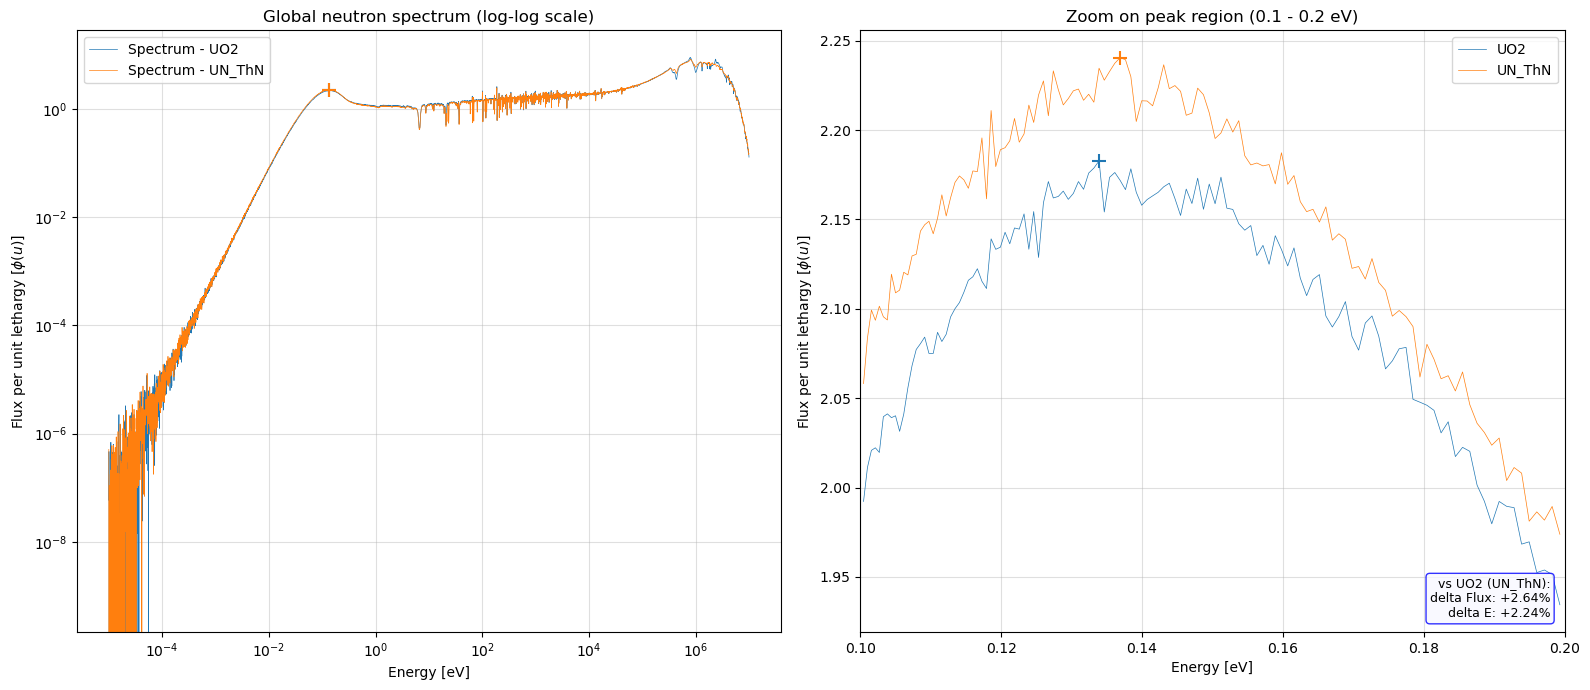

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
peak_results = {}

# 2. Pre-calculate grid properties for lethargy normalization
lethargy_widths = np.log(energies[1:] / energies[:-1])
energy_centers = np.sqrt(energies[:-1] * energies[1:])

# 3. Define masks for specific spectral regions
zoom_mask = (energy_centers >= 0.1) & (energy_centers <= 0.2)
thermal_mask = energy_centers < 1.0

# Iterate through spectra to plot and identify thermal peaks
for name, spectrum in results_spectrum.items():
    # Normalize flux per unit lethargy
    y_lethargy = spectrum / lethargy_widths
    
    # --- Plot 1: Global spectrum (log-log representation) ---
    ax1.loglog(energy_centers, y_lethargy, label=f"Spectrum - {name}", lw=0.5)
    
    # --- Plot 2: Resonance region visualization ---
    ax2.plot(energy_centers[zoom_mask], y_lethargy[zoom_mask], label=f"{name}", lw=0.5)

    # --- Thermal peak detection and tracking ---
    idx = np.argmax(y_lethargy[thermal_mask])
    peak_E = energy_centers[idx]
    peak_val = y_lethargy[idx]
    peak_results[name] = (peak_E, peak_val)
    
    # Add visual markers to identify peaks in both views
    ax1.scatter(peak_E, peak_val, marker='+', s=100, zorder=5)
    ax2.scatter(peak_E, peak_val, marker='+', s=100, zorder=5) 
    
    # Log peak identification results
    print(f"[{name}] Thermal peak energy: {peak_E:.8f} eV | Magnitude: {peak_val:.4f}") 

# Formatting Plot 1: Global View
ax1.set_xlabel('Energy [eV]')
ax1.set_ylabel(r'Flux per unit lethargy [$\phi(u)$]')
ax1.set_title('Global neutron spectrum (log-log scale)')
ax1.grid(True, which="both", ls="-", alpha=0.4)
ax1.legend()

# Formatting Plot 2: Detailed Zoom View
ax2.set_xlabel('Energy [eV]')
ax2.set_ylabel(r'Flux per unit lethargy [$\phi(u)$]')
ax2.set_title('Zoom on peak region (0.1 - 0.2 eV)')
ax2.set_xlim(0.1, 0.2) 
ax2.grid(True, which="both", ls="-", alpha=0.4)
ax2.legend()

# Perform cross-comparison against UO2 reference case
if 'UO2' in peak_results:
    e_ref, v_ref = peak_results['UO2']
    
    for name, (peak_E, peak_val) in peak_results.items():
        if name == 'UO2': continue  # Skip self-comparison
        
        # Calculate percentage differences
        diff_val = ((peak_val - v_ref) / v_ref) * 100
        diff_E = ((peak_E - e_ref) / e_ref) * 100
        
        comparison_text = (
            f"vs UO2 ({name}):\n"
            f"delta Flux: {diff_val:+.2f}%\n"
            f"delta E: {diff_E:+.2f}%"
        )
        
        # Annotate zoom plot with relative comparison data
        ax2.text(0.98, 0.02, comparison_text, transform=ax2.transAxes,
                 va='bottom', ha='right', fontsize=9,
                 bbox=dict(boxstyle="round", fc="ghostwhite", ec="blue", alpha=0.8))
        
        print(f"delta Flux: {diff_val:+.2f}% | delta E: {diff_E:+.2f}%")
        
plt.savefig('./res/Neutron_Spectrum_log_log.png')
plt.tight_layout()
plt.show()

| Parameter | UO2 | UN-ThN | Relative Difference |
| :--- | :--- | :--- | :--- |
| **Peak Energy** | 0.1339 eV | 0.1369 eV | **+2.24%** |
| **Magnitude** | 2.1828 | 2.2405 | **+2.64%** |

*In agreement with Ishraq & Roy (2024), where the UO2 and UN-ThN peaks are found to be very close.*

#### C1. Spectrum Hardening (+2.24% Energy Shift)
The high atomic density of the Nitride matrix (UN-ThN) increases the macroscopic absorption cross-section for the lowest-energy thermal neutrons. This preferentially removes "colder" neutrons, shifting the thermal equilibrium peak to the right. This shift confirms a slightly harder spectrum while remaining within the thermal regime.

#### C2. Thermal Peak Stability (+2.64% Magnitude)
The slight increase in magnitude suggests a concentration of the thermal population. Nitrogen ($^{14}N$) has a low capture cross-section, letting neutrons "bounce back" into the water to finish their cooling process. This ensures that the transition to UN-ThN does not penalize the thermal neutron economy.


Average relative difference in resonance region (UN-ThN vs UO2): -3.79%


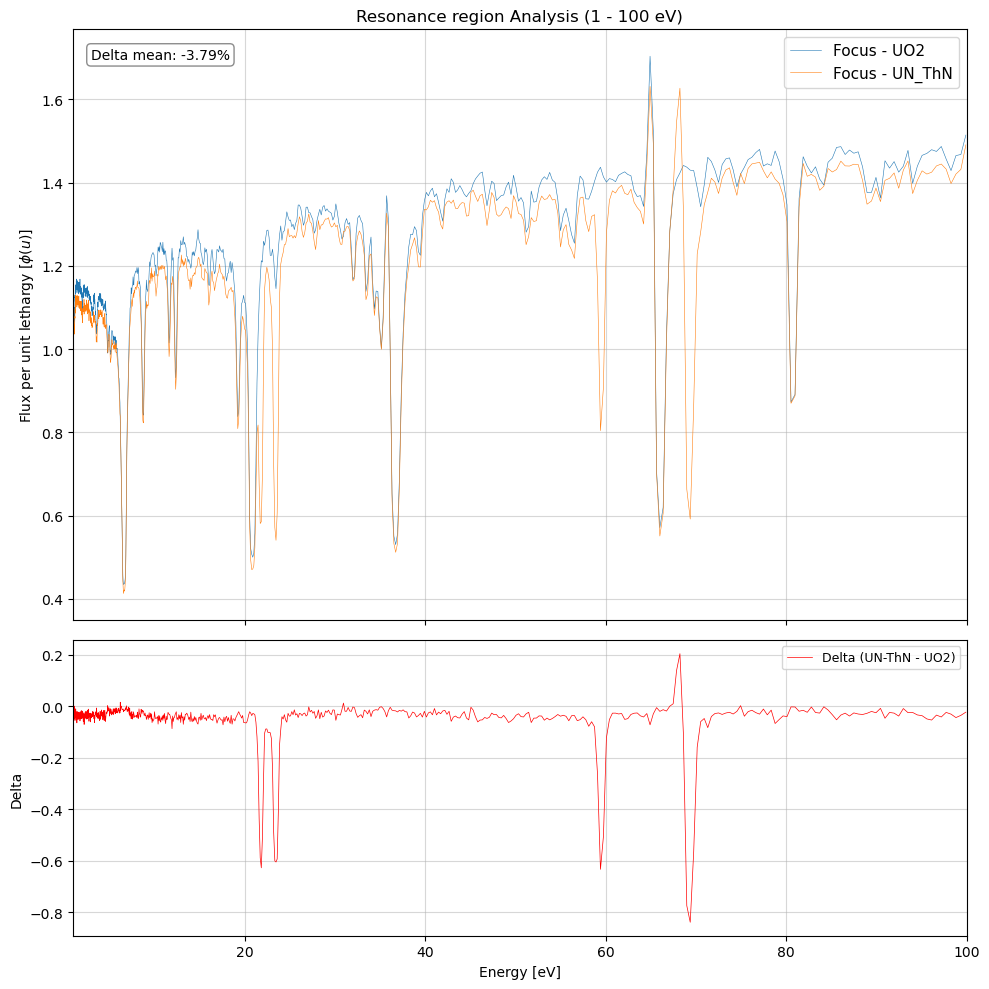

In [14]:
# =================================================================
# PART 2: THE STANDALONE ZOOM (Resonance Analysis 1-100 eV)
# =================================================================
# Create two subplots: top for spectra, bottom for the delta
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

resonance_mask = (energy_centers >= 1.0) & (energy_centers <= 100.0)

for name, spectrum in results_spectrum.items():
    y_lethargy = spectrum / lethargy_widths
    # Top plot: Spectra
    ax1.plot(energy_centers[resonance_mask], y_lethargy[resonance_mask], label=f"Focus - {name}", lw=0.4)

# Formatting Top Plot
ax1.set_title('Resonance region Analysis (1 - 100 eV)', fontsize=12)
ax1.set_ylabel(r'Flux per unit lethargy [$\phi(u)$]', fontsize=10)
ax1.grid(True, which="major", ls="-", alpha=0.5)
ax1.legend(fontsize=11)

# Add statistical annotation and Delta subplot
if 'UO2' in results_spectrum and 'UN_ThN' in results_spectrum:
    y_uo2 = (results_spectrum['UO2'] / lethargy_widths)[resonance_mask]
    y_unthn = (results_spectrum['UN_ThN'] / lethargy_widths)[resonance_mask]
    
    # Local relative difference
    local_diff = y_unthn - y_uo2
    rel_impact = np.mean((y_unthn - y_uo2) / y_uo2 * 100)
    
    # Top plot annotation
    ax1.annotate(f"Delta mean: {rel_impact:+.2f}%", 
                 xy=(0.02, 0.95), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9),
                 fontsize=10)
    
    # Bottom plot: Delta
    ax2.plot(energy_centers[resonance_mask], local_diff, color='red', lw=0.5, label='Delta (UN-ThN - UO2)')
    ax2.set_ylabel('Delta', fontsize=10)
    ax2.set_xlabel('Energy [eV]', fontsize=10)
    ax2.grid(True, which="major", ls="-", alpha=0.5)
    ax2.set_xlim(1, 100)
    ax2.legend(fontsize=9)

    print(f"\nAverage relative difference in resonance region (UN-ThN vs UO2): {rel_impact:+.2f}%")

plt.tight_layout()
plt.savefig('./res/Spectrum_Standalone_Zoom_with_Delta.png')
plt.show()

#### C3. Resonance Region Impact (1 - 100 eV)
The average relative difference in flux is **-3.79%** is directly attributed to the higher resonance integral of Thorium-232. The massive capture resonances of $^{232}Th$ act as a "neutron sink" during the slowing-down process. This creates a **flux depression** in the epithermal range, it characterizes the fertile capture efficiency of the Thorium cycle.

*(In reality, these neutrons are not lost ; they are intercepted by $^{232}\text{Th}$ during their slowing down (effectively initiating the conversion process into fissile $^{233}\text{U}$).)*

#### C4. Conclusion

In summary, the transition to **UN-ThN** produces a thermal spectrum that is **harder yet more concentrated** (peak shifted to the right with increased magnitude), while creating a marked **flux depression** in the resonance region. This redistribution of neutron energy reflects a denser medium where fertile capture becomes more competitive during the moderation process.

### D. Radial power distribution (The "self-shielding" effect)
This allows us to visualize the fission rate according to the pellet radius, capturing the spatial self-shielding effect. Analyzing the radial power profile is critical for comparing how high heavy-metal density and Thorium’s cross-sections influence fission homogeneity. 

#### D1. 2D - Heatmap
This 2D heatmap visualizes the fission density across the entire pellet cross-section. By employing a shared scale, it provides an immediate comparison of neutronic opacity between the two fuels.

In [15]:
# # Prepare data for the 1D Heatmap
# data_uo2 = results_power['UO2'].reshape(1, -1)
# data_unthn = results_power['UN_ThN'].reshape(1, -1)

# # Setup the subplots
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4))
# plt.subplots_adjust(hspace=0.6)

# # Find global min/max for a shared scale
# v_min = min(data_uo2.min(), data_unthn.min())
# v_max = max(data_uo2.max(), data_unthn.max())

# # --- Plot 1: UO2 Reference ---
# im1 = ax1.imshow(data_uo2, cmap='viridis', aspect='auto', 
#                  extent=[0, fuel_or, 0, 1], vmin=v_min, vmax=v_max)
# ax1.set_title("Radial Fission Density Ribbon: UO2 (Reference)", fontweight='bold')
# ax1.set_yticks([]) 
# ax1.set_xlabel("Radius [cm] (Center -> Edge)")

# # --- Plot 2: UN-ThN Advanced Fuel ---
# im2 = ax2.imshow(data_unthn, cmap='viridis', aspect='auto', 
#                  extent=[0, fuel_or, 0, 1], vmin=v_min, vmax=v_max)
# ax2.set_title("Radial Fission Density Ribbon: UN-ThN (Advanced Matrix)", fontweight='bold')
# ax2.set_yticks([])
# ax2.set_xlabel("Radius [cm] (Center -> Edge)")

# # Add a unified colorbar for both plots to ensure visual consistency
# cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
# fig.colorbar(im1, cax=cbar_ax, label='Fission Rate [fissions/src-n]')

# plt.savefig('./res/2D_Heatmap_Radial_Fission_Density.png')
# plt.show()

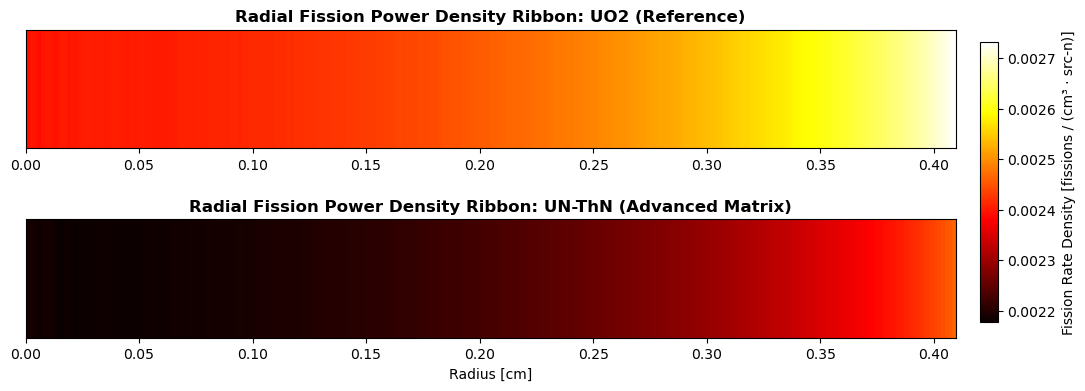

In [16]:
# --- PARAMETERS FOR NORMALIZATION ---
data_uo2 = results_power['UO2'].reshape(1, -1)
# R_PELLET matches fuel_or (0.4096 cm)
R_PELLET = fuel_or  
N_BINS = data_uo2.shape[1] if 'data_uo2' in locals() else results_power['UO2'].shape[0]

# Calculate the volume of each annular bin (couronne cylindrique) in cm^3
r_edges = np.linspace(0, R_PELLET, N_BINS + 1)
# Volume = pi * (r_out^2 - r_in^2) * active_height (420 cm)
volumes = np.pi * (r_edges[1:]**2 - r_edges[:-1]**2) * 420.0

# --- DATA PREPARATION WITH DENSITY NORMALIZATION ---
# Extract and flatten first to apply the volume division element-wise
uo2_raw = results_power['UO2'].flatten()[:N_BINS]
unthn_raw = results_power['UN_ThN'].flatten()[:N_BINS]

# Divide by volume to get Fission Rate Density [fissions / (cm³ · src-neutron)]
data_uo2_density = (uo2_raw / volumes).reshape(1, -1)
data_unthn_density = (unthn_raw / volumes).reshape(1, -1)

# Setup the subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4))
plt.subplots_adjust(hspace=0.6)

# Find global min/max for a shared scale based on densities
v_min = min(data_uo2_density.min(), data_unthn_density.min())
v_max = max(data_uo2_density.max(), data_unthn_density.max())

# --- Plot 1: UO2 Reference ---
im1 = ax1.imshow(data_uo2_density, cmap='hot', aspect='auto', 
                 extent=[0, fuel_or, 0, 1], vmin=v_min, vmax=v_max)
ax1.set_title("Radial Fission Power Density Ribbon: UO2 (Reference)", fontweight='bold')
ax1.set_yticks([]) 

# --- Plot 2: UN-ThN Advanced Fuel ---
im2 = ax2.imshow(data_unthn_density, cmap='hot', aspect='auto', 
                 extent=[0, fuel_or, 0, 1], vmin=v_min, vmax=v_max)
ax2.set_title("Radial Fission Power Density Ribbon: UN-ThN (Advanced Matrix)", fontweight='bold')
ax2.set_yticks([])
ax2.set_xlabel("Radius [cm]")

# Add a unified colorbar with updated unit label
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im1, cax=cbar_ax, label='Fission Rate Density [fissions / (cm³ · src-n)]')

# Save the result
os.makedirs("./res", exist_ok=True)
plt.savefig('./res/2D_Heatmap_Radial_Fission_Density.png', dpi=300)
plt.show()

#### D2. Quantitative profile along $(r)$

*A flatter profile signifies better fuel utilization at the pellet's core and mitigates local thermo-mechanical stress.*

Fuel     | Slope      | e^Slope    | Prof Factor  | Delta Index  | Delta Slope     | Mean Delta   | Std Delta   
------------------------------------------------------------------------------------------------------------
UO2      | 0.0364     | 1.0371     | 1.0098       | 0.0083       | 4.0206e-06      | 3.5043e-05   | 3.5994e-07  
UN-ThN   | 0.0284     | 1.0288     | 1.0087       | -            | -               | -            | -           


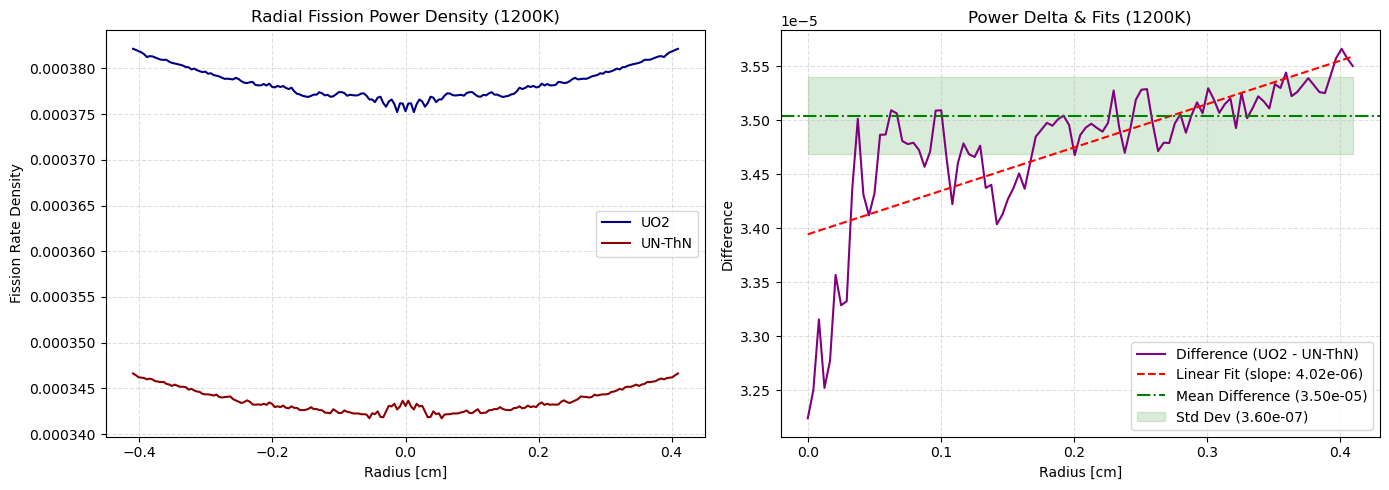

In [34]:
# --- Parameters ---
R_PELLET = 0.4095
N_BINS   = 99
x_axis   = np.linspace(0, R_PELLET, N_BINS)
x_full   = np.concatenate([-x_axis[::-1], x_axis])

# Bin volume calculation for weighted average
r_edges = np.linspace(0, R_PELLET, N_BINS + 1)
volumes = np.pi * (r_edges[1:]**2 - r_edges[:-1]**2) * 420

# Files for 900K only
file_uo2 = "statepoint_UO2_900K.h5"
file_unthn = "statepoint_UN_ThN_900K.h5"

# --- Extraction and Calculations ---
with openmc.StatePoint(file_uo2) as sp:
    raw_uo2 = sp.get_tally(name='radial_power').get_values(scores=['fission']).flatten()[:N_BINS]
    density_uo2_half = raw_uo2 / volumes
    density_uo2_full = np.concatenate([density_uo2_half[::-1], density_uo2_half])
    
    # Profile factor (Max / Weighted Average)
    mean_uo2 = np.mean(density_uo2_half)  
    prof_factor_uo2 = np.max(density_uo2_half) / mean_uo2
    
    # Self-shielding slope
    norm_uo2 = density_uo2_half / mean_uo2
    slope_uo2, _ = np.polyfit(x_axis, np.log(norm_uo2 + 1e-15), 1)

with openmc.StatePoint(file_unthn) as sp:
    raw_unthn = sp.get_tally(name='radial_power').get_values(scores=['fission']).flatten()[:N_BINS]
    density_unthn_half = raw_unthn / volumes
    density_unthn_full = np.concatenate([density_unthn_half[::-1], density_unthn_half])
    
    # Profile factor
    mean_unthn = np.mean(density_unthn_half)
    prof_factor_unthn = np.max(density_unthn_half) / mean_unthn
    
    # Self-shielding slope
    norm_unthn = density_unthn_half / mean_unthn
    slope_unthn, _ = np.polyfit(x_axis, np.log(norm_unthn + 1e-15), 1)

# --- Delta and Deviations Calculations ---
diff_half = density_uo2_half - density_unthn_half
slope_delta, intercept_delta = np.polyfit(x_axis, diff_half, 1)
fit_line_delta = slope_delta * x_axis + intercept_delta

# Mean deviation and Standard Deviation (weighted by bin volumes)
total_volume = np.sum(volumes)
mean_diff  = np.sum(diff_half * volumes) / total_volume
variance_diff = np.sum(volumes * (diff_half - mean_diff)**2) / total_volume
std_diff = np.sqrt(variance_diff)

# --- Table Display ---
print(f"{'Fuel':<8} | {'Slope':<10} | {'e^Slope':<10} | {'Prof Factor':<12} | {'Delta Index':<12} | {'Delta Slope':<15} | {'Mean Delta':<12} | {'Std Delta':<12}")
print("-" * 108)
print(f"{'UO2':<8} | {slope_uo2:<10.4f} | {np.exp(slope_uo2):<10.4f} | {prof_factor_uo2:<12.4f} | {np.exp(slope_uo2) - np.exp(slope_unthn):<12.4f} | {slope_delta:<15.4e} | {mean_diff:<12.4e} | {std_diff:<12.4e}")
print(f"{'UN-ThN':<8} | {slope_unthn:<10.4f} | {np.exp(slope_unthn):<10.4f} | {prof_factor_unthn:<12.4f} | {'-':<12} | {'-':<15} | {'-':<12} | {'-':<12}")

# --- Plots (1200K) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Full profiles
ax1.plot(x_full, density_uo2_full, '-', label='UO2', color='navy')
ax1.plot(x_full, density_unthn_full, '-', label='UN-ThN', color='darkred')
ax1.set_title('Radial Fission Power Density (1200K)')
ax1.set_xlabel('Radius [cm]')
ax1.set_ylabel('Fission Rate Density')
ax1.grid(True, ls="--", alpha=0.4)
ax1.legend()

# Plot 2: Difference + Linear Fit + Mean Line + Std Dev Shade
ax2.plot(x_axis, diff_half, '-', label='Difference (UO2 - UN-ThN)', color='purple')
ax2.plot(x_axis, fit_line_delta, '--', color='red', label=f'Linear Fit (slope: {slope_delta:.2e})')
ax2.axhline(y=mean_diff, color='green', ls='-.', label=f'Mean Difference ({mean_diff:.2e})')
# Zone ombragée verte représentant l'écart-type
ax2.fill_between(x_axis, mean_diff - std_diff, mean_diff + std_diff, color='green', alpha=0.15, label=f'Std Dev ({std_diff:.2e})')

ax2.set_title('Power Delta & Fits (1200K)')
ax2.set_xlabel('Radius [cm]')
ax2.set_ylabel('Difference')
ax2.grid(True, ls="--", alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.savefig("res/radial_power_delta_at_1200K.png", dpi=300)
plt.show()

Fuel     | Slope      | e^Slope    | Prof Factor  | Delta Index  | Delta Slope     | Mean Delta   | Std Delta   
------------------------------------------------------------------------------------------------------------
UO2      | 0.0382     | 1.0389     | 1.0096       | 0.0022       | 2.1065e-06      | 3.6141e-05   | 2.8764e-07  
UN-ThN   | 0.0360     | 1.0367     | 1.0100       | -            | -               | -            | -           


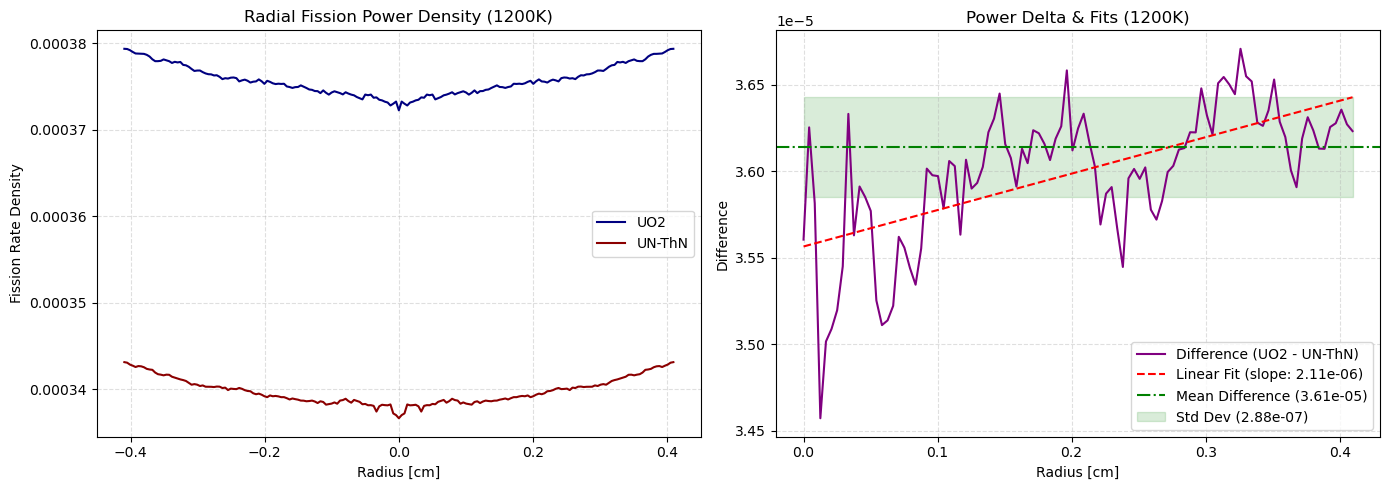

In [ ]:
# --- Parameters ---
R_PELLET = 0.4095
N_BINS   = 99
x_axis   = np.linspace(0, R_PELLET, N_BINS)
x_full   = np.concatenate([-x_axis[::-1], x_axis])

# Bin volume calculation for weighted average
r_edges = np.linspace(0, R_PELLET, N_BINS + 1)
volumes = np.pi * (r_edges[1:]**2 - r_edges[:-1]**2) * 420

# Files for 1200K only
file_uo2 = "statepoint_UO2_1200K.h5"
file_unthn = "statepoint_UN_ThN_1200K.h5"

# --- Extraction and Calculations ---
with openmc.StatePoint(file_uo2) as sp:
    raw_uo2 = sp.get_tally(name='radial_power').get_values(scores=['fission']).flatten()[:N_BINS]
    density_uo2_half = raw_uo2 / volumes
    density_uo2_full = np.concatenate([density_uo2_half[::-1], density_uo2_half])
    
    # Profile factor (Max / Weighted Average)
    mean_uo2 = np.mean(density_uo2_half)  
    prof_factor_uo2 = np.max(density_uo2_half) / mean_uo2
    
    # Self-shielding slope
    norm_uo2 = density_uo2_half / mean_uo2
    slope_uo2, _ = np.polyfit(x_axis, np.log(norm_uo2 + 1e-15), 1)

with openmc.StatePoint(file_unthn) as sp:
    raw_unthn = sp.get_tally(name='radial_power').get_values(scores=['fission']).flatten()[:N_BINS]
    density_unthn_half = raw_unthn / volumes
    density_unthn_full = np.concatenate([density_unthn_half[::-1], density_unthn_half])
    
    # Profile factor
    mean_unthn = np.mean(density_unthn_half)
    prof_factor_unthn = np.max(density_unthn_half) / mean_unthn
    
    # Self-shielding slope
    norm_unthn = density_unthn_half / mean_unthn
    slope_unthn, _ = np.polyfit(x_axis, np.log(norm_unthn + 1e-15), 1)

# --- Delta and Deviations Calculations ---
diff_half = density_uo2_half - density_unthn_half
slope_delta, intercept_delta = np.polyfit(x_axis, diff_half, 1)
fit_line_delta = slope_delta * x_axis + intercept_delta

# Mean deviation and Standard Deviation (weighted by bin volumes)
total_volume = np.sum(volumes)
mean_diff  = np.sum(diff_half * volumes) / total_volume
variance_diff = np.sum(volumes * (diff_half - mean_diff)**2) / total_volume
std_diff = np.sqrt(variance_diff)

# --- Table Display ---
print(f"{'Fuel':<8} | {'Slope':<10} | {'e^Slope':<10} | {'Prof Factor':<12} | {'Delta Index':<12} | {'Delta Slope':<15} | {'Mean Delta':<12} | {'Std Delta':<12}")
print("-" * 108)
print(f"{'UO2':<8} | {slope_uo2:<10.4f} | {np.exp(slope_uo2):<10.4f} | {prof_factor_uo2:<12.4f} | {np.exp(slope_uo2) - np.exp(slope_unthn):<12.4f} | {slope_delta:<15.4e} | {mean_diff:<12.4e} | {std_diff:<12.4e}")
print(f"{'UN-ThN':<8} | {slope_unthn:<10.4f} | {np.exp(slope_unthn):<10.4f} | {prof_factor_unthn:<12.4f} | {'-':<12} | {'-':<15} | {'-':<12} | {'-':<12}")

# --- Plots (1200K) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Full profiles
ax1.plot(x_full, density_uo2_full, '-', label='UO2', color='navy')
ax1.plot(x_full, density_unthn_full, '-', label='UN-ThN', color='darkred')
ax1.set_title('Radial Fission Power Density (1200K)')
ax1.set_xlabel('Radius [cm]')
ax1.set_ylabel('Fission Rate Density')
ax1.grid(True, ls="--", alpha=0.4)
ax1.legend()

# Plot 2: Difference + Linear Fit + Mean Line + Std Dev Shade
ax2.plot(x_axis, diff_half, '-', label='Difference (UO2 - UN-ThN)', color='purple')
ax2.plot(x_axis, fit_line_delta, '--', color='red', label=f'Linear Fit (slope: {slope_delta:.2e})')
ax2.axhline(y=mean_diff, color='green', ls='-.', label=f'Mean Difference ({mean_diff:.2e})')
# Zone ombragée verte représentant l'écart-type
ax2.fill_between(x_axis, mean_diff - std_diff, mean_diff + std_diff, color='green', alpha=0.15, label=f'Std Dev ({std_diff:.2e})')

ax2.set_title('Power Delta & Fits (1200K)')
ax2.set_xlabel('Radius [cm]')
ax2.set_ylabel('Difference')
ax2.grid(True, ls="--", alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.savefig("res/radial_power_delta_at_1200K.png", dpi=300)
plt.show()

### Spatial Self-Shielding and Thermal Effects Analysis

| Temperature | Fuel Type | Self-Shielding Slope | Delta Slope (UO2 - UN-ThN) | Shielding Index (e^slope) | Delta Index (UO2 - UN-ThN) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **900 K** | UO2 | 7.2376 | 4.0e-06 | 1390.7078 | **+11.1080** |
| **900 K** | UN-ThN | 7.2295 | | 1379.5998 | |
| **1200 K** | UO2 | 7.2394 | 2.10e-06 | 1393.2072 | **+3.0066** |
| **1200 K** | UN-ThN | 7.2372 | | 1390.2006 | |

The analysis of the normalized power profiles provides a quantification of the spatial self-shielding effect through the shielding index ($e^{\text{slope}}$). 

With a lower shielding index ($1379.6$ compared to $1390.7$ at $900\text{ K}$), the Thorium-232 bearing matrix allows the thermal neutron flux to penetrate marginally deeper toward the pellet centerline than the standard $\text{UO}_2$. While it promotes a more uniform power deposition, the significantly higher thermal conductivity inherent to nitride fuels ($13\text{ to }15\text{ W}\cdot\text{m}^{-1}\cdot\text{K}^{-1}$ for $\text{UN-ThN}$) over oxides ($\sim 3\text{ W}\cdot\text{m}^{-1}\cdot\text{K}^{-1}$ for $\text{UO}_2$ at these temperatures) heavily outweighs this spatial effect. 

As temperature increases to $1200\text{ K}$ the steepening of the index is higher for UNThN ($+0.77\%$) than UO2 ($+0.18\%$), indicating that the nitride-thorium matrix is significantly more sensitive to thermal spectrum hardening, leading to a more pronounced migration of fissions toward the pellet periphery. The fact that the slope of the delta curve ($\text{UO}_2 - \text{UN-ThN}$) decreases drastically (being nearly cut in half) demonstrates that $\text{UN-ThN}$ undergoes a significantly more aggressive change of its power profile than $\text{UO}_2$ under thermal influence. Concurrently, the delta index between $\text{UO}_2$ and $\text{UN-ThN}$ drops sharply from $+11.1$ to $+3.0$. This convergence highlights the effect of Doppler broadening of the capture resonances at higher temperatures, which acts to smooth out the macroscopic absorption differences between the two fuel matrices.

Fuel     | Temp   | Slope      | e^Slope    | Delta Idx  | Slope Delta  | Mean Delta   | Std Delta   
---------------------------------------------------------------------------------------------------------------------
UO2      | 900K   | 0.0364     | 1.0371     | -0.0019    | -5.7555e-07  | 2.6295e-06   | 2.3688e-07  
UO2      | 1200K  | 0.0382     | 1.0389     | -          | -            | -            | -           
---------------------------------------------------------------------------------------------------------------------


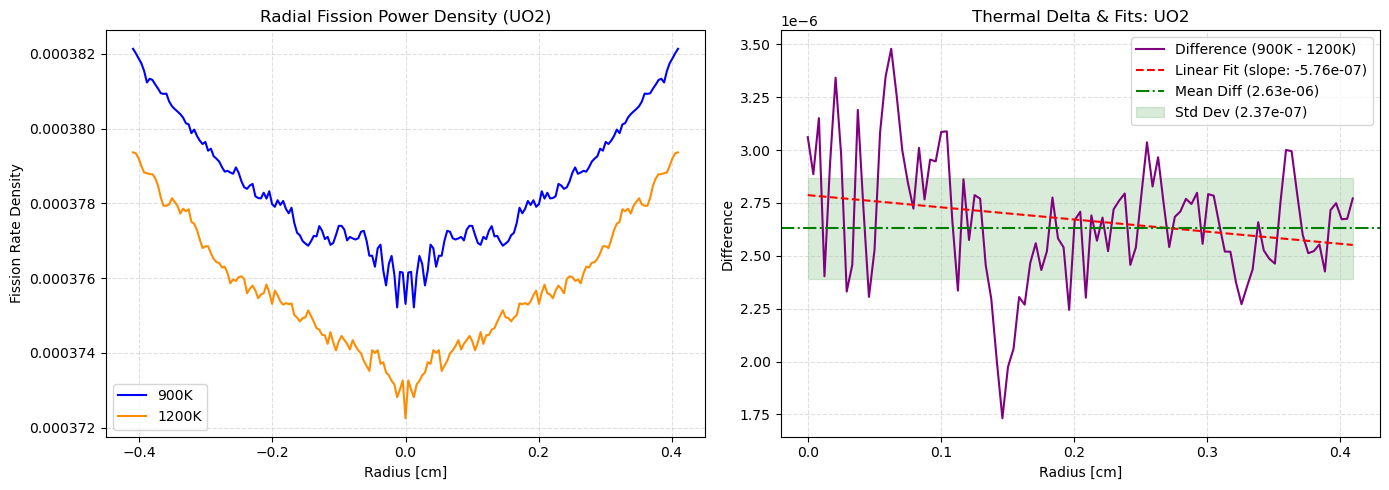

UN_ThN   | 900K   | 0.0284     | 1.0288     | -0.0079    | -2.4896e-06  | 3.7268e-06   | 2.5998e-07  
UN_ThN   | 1200K  | 0.0360     | 1.0367     | -          | -            | -            | -           
---------------------------------------------------------------------------------------------------------------------


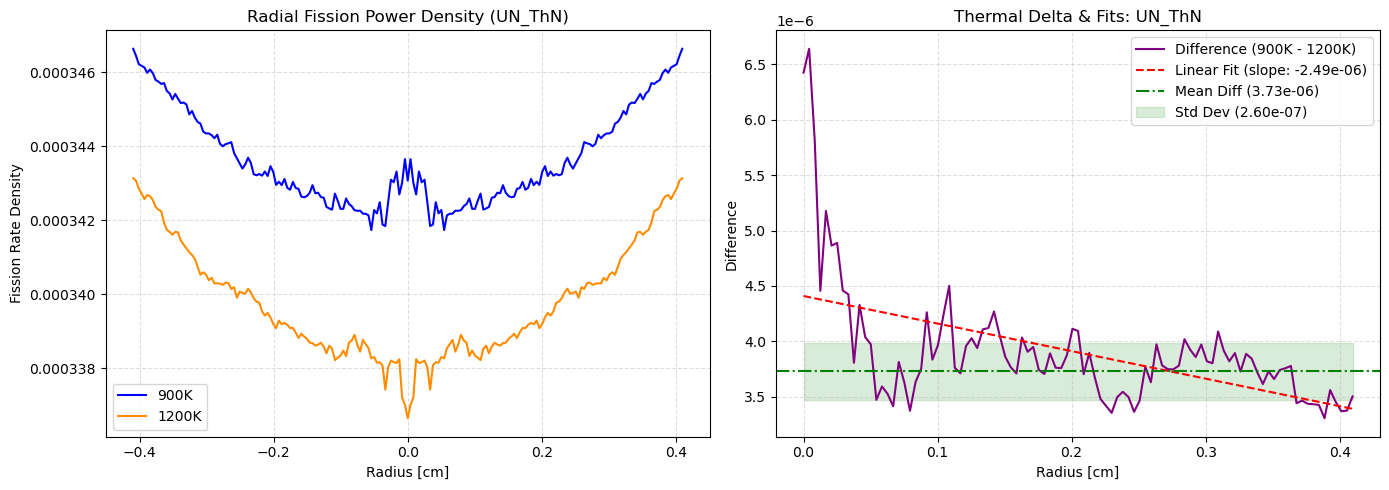

In [32]:
import numpy as np
import os
import openmc
import matplotlib.pyplot as plt

# --- Parameters ---
R_PELLET = 0.4095
N_BINS   = 99
x_axis   = np.linspace(0, R_PELLET, N_BINS)
x_full   = np.concatenate([-x_axis[::-1], x_axis])

# Bin volumes
r_edges = np.linspace(0, R_PELLET, N_BINS + 1)
volumes = np.pi * (r_edges[1:]**2 - r_edges[:-1]**2) * 420

# Fuel configurations
fuels = [
    {"name": "UO2",   "f900": "statepoint_UO2_900K.h5",   "f1200": "statepoint_UO2_1200K.h5"},
    {"name": "UN_ThN","f900": "statepoint_UN_ThN_900K.h5","f1200": "statepoint_UN_ThN_1200K.h5"}
]

# En-tête du tableau mis à jour avec les colonnes Mean Delta et Std Delta
print(f"{'Fuel':<8} | {'Temp':<6} | {'Slope':<10} | {'e^Slope':<10} | {'Delta Idx':<10} | {'Slope Delta':<12} | {'Mean Delta':<12} | {'Std Delta':<12}")
print("-" * 117)

for f in fuels:
    if not os.path.exists(f["f900"]) or not os.path.exists(f["f1200"]):
        print(f"Missing files for {f['name']}. Step skipped.")
        continue

    # --- 900K Processing ---
    with openmc.StatePoint(f["f900"]) as sp:
        raw_900  = sp.get_tally(name='radial_power').get_values(scores=['fission']).flatten()[:N_BINS]
        dens_900 = raw_900 / volumes
        dens_900_full = np.concatenate([dens_900[::-1], dens_900])

        mean_900  = np.mean(dens_900)
        norm_900  = dens_900 / mean_900
        slope_900, _ = np.polyfit(x_axis, np.log(norm_900 + 1e-15), 1)

    # --- 1200K Processing ---
    with openmc.StatePoint(f["f1200"]) as sp:
        raw_1200  = sp.get_tally(name='radial_power').get_values(scores=['fission']).flatten()[:N_BINS]
        dens_1200 = raw_1200 / volumes
        dens_1200_full = np.concatenate([dens_1200[::-1], dens_1200])

        mean_1200  = np.mean(dens_1200)
        norm_1200  = dens_1200 / mean_1200
        slope_1200, _ = np.polyfit(x_axis, np.log(norm_1200 + 1e-15), 1)

    # --- Deltas (900K - 1200K) ---
    diff_half = dens_900 - dens_1200
    slope_delta, intercept_delta = np.polyfit(x_axis, diff_half, 1)
    fit_delta  = slope_delta * x_axis + intercept_delta
    
    # Calcul de la moyenne et de l'écart-type pondérés par le volume des couronnes (bins)
    total_volume = np.sum(volumes)
    mean_diff  = np.sum(diff_half * volumes) / total_volume
    variance_diff = np.sum(volumes * (diff_half - mean_diff)**2) / total_volume
    std_diff = np.sqrt(variance_diff)

    delta_idx = np.exp(slope_900) - np.exp(slope_1200)

    # --- Display ---
    print(f"{f['name']:<8} | {'900K':<6} | {slope_900:<10.4f} | {np.exp(slope_900):<10.4f} | {delta_idx:<10.4f} | {slope_delta:<12.4e} | {mean_diff:<12.4e} | {std_diff:<12.4e}")
    print(f"{f['name']:<8} | {'1200K':<6} | {slope_1200:<10.4f} | {np.exp(slope_1200):<10.4f} | {'-':<10} | {'-':<12} | {'-':<12} | {'-':<12}")
    print("-" * 117)

    # --- Plots ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(x_full, dens_900_full,  '-', label='900K',  color='blue')
    ax1.plot(x_full, dens_1200_full, '-', label='1200K', color='darkorange')
    ax1.set_title(f'Radial Fission Power Density ({f["name"]})')
    ax1.set_xlabel('Radius [cm]')
    ax1.set_ylabel('Fission Rate Density')
    ax1.grid(True, ls="--", alpha=0.4)
    ax1.legend()

    ax2.plot(x_axis, diff_half, '-',  label='Difference (900K - 1200K)', color='purple')
    ax2.plot(x_axis, fit_delta,  '--', color='red',   label=f'Linear Fit (slope: {slope_delta:.2e})')
    ax2.axhline(y=mean_diff, color='green', ls='-.', label=f'Mean Diff ({mean_diff:.2e})')
    # Ajout visuel d'une zone ombragée représentant l'écart-type autour de la moyenne sur le graphique
    ax2.fill_between(x_axis, mean_diff - std_diff, mean_diff + std_diff, color='green', alpha=0.15, label=f'Std Dev ({std_diff:.2e})')
    ax2.set_title(f'Thermal Delta & Fits: {f["name"]}')
    ax2.set_xlabel('Radius [cm]')
    ax2.set_ylabel('Difference')
    ax2.grid(True, ls="--", alpha=0.4)
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"res/radial_power_temp_variation_{f['name']}.png", dpi=300)
    plt.show()

| Fuel | Temp | Slope | e^Slope | Delta Idx | Slope Delta | Mean Delta | Std Delta |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| UO2 | 900K | 0.0364 | 1.0371 | -0.0019 | -5.7555e-07 | 2.6295e-06 | 2.3688e-07 |
| UO2 | 1200K | 0.0382 | 1.0389 | - | - | - | - |
| UN_ThN | 900K | 0.0284 | 1.0288 | -0.0079 | -2.4896e-06 | 3.7268e-06 | 2.5998e-07 |
| UN_ThN | 1200K | 0.0360 | 1.0367 | - | - | - | - |


By comparing the radial power profiles of the same fuel at different temperatures, the 4.3-fold steeper slope (on the temperature-induced delta power) observed for UN-ThN ($2.49 \times 10^{-6}$) compared to UO$_2$ ($5.75 \times 10^{-7}$) quantitatively confirms that the nitride-thorium matrix undergoes a much more rapid and aggressive spatial redistribution of fissions under thermal hardening than the oxide fuel.

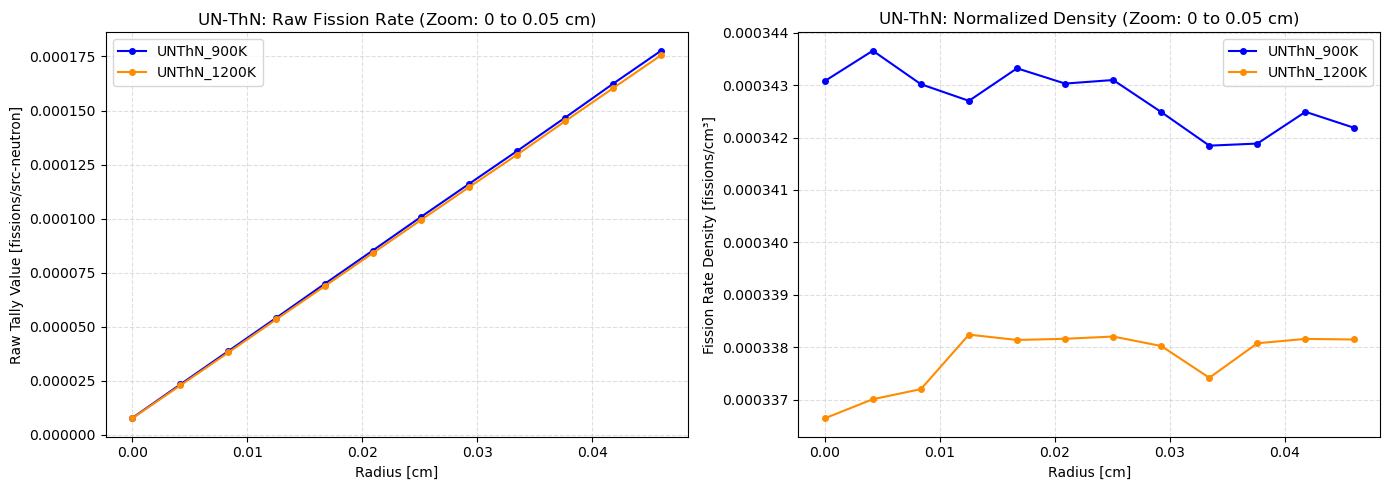

In [27]:
# --- Parameters ---
R_PELLET = 0.4095
N_BINS   = 99
x_axis   = np.linspace(0, R_PELLET, N_BINS)

# Exclusive selection of the 0 to 0.05 cm zone
mask = x_axis <= 0.05
x_zoom = x_axis[mask]

# Bin volumes calculation (in cm³)
r_edges = np.linspace(0, R_PELLET, N_BINS + 1)
volumes = np.pi * (r_edges[1:]**2 - r_edges[:-1]**2) * 420

# Configuration: UN-ThN only
cases = {
    "UNThN_900K":  {"file": "statepoint_UN_ThN_900K.h5", "color": "blue"},
    "UNThN_1200K": {"file": "statepoint_UN_ThN_1200K.h5", "color": "darkorange"}
}

# --- Figure Creation (1 row, 2 columns) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, info in cases.items():
    if not os.path.exists(info["file"]):
        print(f"Missing file for {name}, skipped.")
        continue
        
    with openmc.StatePoint(info["file"]) as sp:
        # Extraction of the full right half
        raw_half = sp.get_tally(name='radial_power').get_values(scores=['fission']).flatten()[:N_BINS]
        density_half = raw_half / volumes
        
        # Applying the [0, 0.05] filter
        raw_zoom = raw_half[mask]
        density_zoom = density_half[mask]
        
        # Plot 1: Zoomed Raw Data
        ax1.plot(x_zoom, raw_zoom, '-o', label=name, color=info["color"], lw=1.5, ms=4)
        
        # Plot 2: Zoomed Normalized Data
        ax2.plot(x_zoom, density_zoom, '-o', label=name, color=info["color"], lw=1.5, ms=4)

# --- Plot 1 Adjustments (Raw Zoom) ---
ax1.set_title('UN-ThN: Raw Fission Rate (Zoom: $0$ to $0.05$ cm)')
ax1.set_xlabel('Radius [cm]')
ax1.set_ylabel('Raw Tally Value [fissions/src-neutron]')
ax1.grid(True, ls="--", alpha=0.4)
ax1.legend()

# --- Plot 2 Adjustments (Normalized Zoom) ---
ax2.set_title('UN-ThN: Normalized Density (Zoom: $0$ to $0.05$ cm)')
ax2.set_xlabel('Radius [cm]')
ax2.set_ylabel('Fission Rate Density [fissions/cm³]')
ax2.grid(True, ls="--", alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.savefig("res/unthn_profiles_zoom_0.05.png", dpi=300)
plt.show()


The central peak for UN-ThN at 900 K is a physical manifestation of the fuel's high neutronic transparency (enhanced by $^{15}\text{N}$ enrichment), which allows thermal neutrons to naturally converge at the pellet centerline (a phenomenon that can be amplified by the high statistical variance inherent to the innermost tally bins). The inversion of the central peak at 1200 K is driven by the temperature-dependent Doppler broadening of Thorium-232 resonance captures, which increases significantly at 1200 K. This creates a self-shielding effect, depleting the thermal flux in the peripheral layers before it can concentrate at the center.

In summary, while the increase in temperature narrows the initial neutronic disparity between the two fuels, the synergy between the nitride's superior Doppler responsiveness and its exceptional thermal conductivity confirms its intrinsic superiority. This convergence illustrates its superior capacity to adapt its power profile dynamically under thermal influence. While its performance advantages (more uniform power deposition and higher thermal conductivity) are undeniable at high-power operation to ensure enhanced safety margins, these intrinsic benefits persist even at lower temperatures. The inversion of the central peak underscores the fuel's high transparency and its aggressive spatial redistribution under thermal hardening. This dynamic behavior highlights the nitride-thorium matrix's superior adaptability. It is physically consistent with the large shielding index delta variation (+11.1 to +3.0) combined with the 4.3-fold steeper increase in the power profile slope for UN-ThN ($+0.77\%$) compared to UO$_2$ ($+0.18\%$); this confirms the much more rapid and aggressive spatial migration of fissions of the nitride matrix. Ultimately, while the oxide remains relatively static, the UN-ThN fuel actively 'reconfigures' its power deposition, demonstrating a superior capacity to respond to thermal spectrum hardening.

### E. Conversion ratio analysis
#### E1. Mathematical definition
$$CR = \frac{\text{Number of fissile nuclei produced}}{\text{Number of fissile nuclei disappeared}}$$

$$CR = \frac{\text{Tally}(Th232, (n,\gamma)) + \text{Tally}(U238, (n,\gamma))}{\text{Tally}(U235, \text{absorption}) + \text{Tally}(U233, \text{absorption})}$$

##### a) Numerator : Production (sum of fertile captures)
It is the total sum of **radiative capture $(n, \gamma)$** events involving all **fertile** isotopes present in the fuel (here: $^{232}\text{Th}$ and $^{238}\text{U}$). Each neutron captured here represents the birth of a future fissile nucleus through a chain of $\beta^-$ decays:
* **Thorium chain:** $^{232}\text{Th} + n \rightarrow ^{233}\text{Th} \xrightarrow{\beta^-} ^{233}\text{Pa} \xrightarrow{\beta^-} \mathbf{^{233}\text{U}}$ (fissile)
* **Uranium chain:** $^{238}\text{U} + n \rightarrow ^{239}\text{U} \xrightarrow{\beta^-} ^{239}\text{Np} \xrightarrow{\beta^-} \mathbf{^{239}\text{Pu}}$ (fissile)

##### b) Denominator : Consumption (sum of fissile absorptions)
The denominator consists of the total sum of disappearance of **fissile** nuclei $^{235}\text{U}$, as well as any $^{233}\text{U}$ or $^{239}\text{Pu}$ produced over time. This occurs via **fission** or **sterile absorption**.

#### E2. The three conversion ratio regimes
* **$CR < 1$ (Converter) :** More "fuel" is consumed than is manufactured, the stock of fissile material decreases over time (almost all current commercial reactors (PWRs, BWRs)).
* **$CR = 1$ (Isogenerator) :** The reactor produces exactly as much fissile material as it consumes. 
* **$CR > 1$ (Breeder) :** The reactor produces more fuel than it burns, the creation of surplus fuel that can be used to start other reactors.

#### E3. Importance of the CR in this study
The Conversion Ratio is the essential for two main reasons :
1.  **Comparison of fuel performance:** Comparing the $CR$ of UO2 and UN-ThN allows us to quantify exactly how much the Thorium matrix improves the **neutron economy**. It proves whether the increased density of the nitride fuel translates into an advantage for fuel breeding or if the parasitic captures negate these gains.

2.  **Model validation through physical consistency:** The $CR$ serves as a "sanity check" for the pincell model. By obtaining $CR$ values that are consistent with established nuclear literature for UO2 and Thorium cycles, we validate that the **OpenMC tallies** are correctly integrating the neutron flux over the resonance regions of $^{232}\text{Th}$ and $^{238}\text{U}$. 

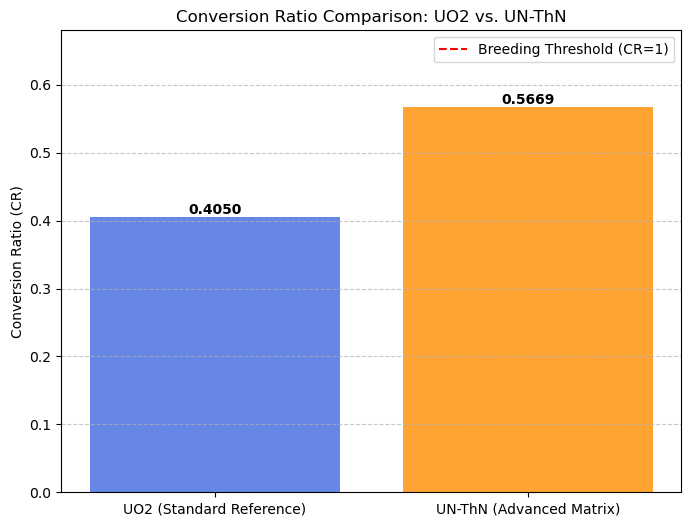

------------------------------------------
FUEL TYPE       | CR         | DIFF %    
------------------------------------------
UO2 Ref         | 0.4050     | +0%       
UN-ThN          | 0.5669     | +39.97%
------------------------------------------


In [20]:
# NUMERATORS: Production (sum radiative capture rates for fertile isotopes).
u238_cap = results_conversion['UO2'].get_values(nuclides=['U238'], scores=['(n,gamma)']).sum()
th232_cap = results_conversion['UN_ThN'].get_values(nuclides=['U238', 'Th232'], scores=['(n,gamma)']).sum()

# DENOMINATORS: Consumption (sum the total absorption (fission + sterile capture) for fissile isotopes).
uo2_abs_fiss = results_conversion['UO2'].get_values(nuclides=['U235'], scores=['absorption']).sum()
unthn_abs_fiss = results_conversion['UN_ThN'].get_values(nuclides=['U235'], scores=['absorption']).sum()

# CR CALCULATION
cr_uo2 = u238_cap / uo2_abs_fiss
cr_unthn = th232_cap / unthn_abs_fiss
diff_percentage = ((cr_unthn - cr_uo2) / cr_uo2) * 100

# VISUALIZATION
labels = ['UO2 (Standard Reference)', 'UN-ThN (Advanced Matrix)']
values = [cr_uo2, cr_unthn]

plt.figure(figsize=(8, 6))
colors = ['royalblue', 'darkorange']
bars = plt.bar(labels, values, color=colors, alpha=0.8)

    # Horizontal line at 1.0 to indicate the breeding threshold
plt.axhline(y=1.0, color='red', linestyle='--', label='Breeding Threshold (CR=1)')

    # Adding labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', 
             va='bottom', ha='center', fontweight='bold')

plt.savefig('./res/Conversion_Ratio_Comparison.png')
plt.ylabel('Conversion Ratio (CR)')
plt.title('Conversion Ratio Comparison: UO2 vs. UN-ThN')
plt.ylim(0, max(values) * 1.2) # Adjust limit to see the threshold clearly
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. METRICS
print("-" * 42)
print(f"{'FUEL TYPE':<15} | {'CR':<10} | {'DIFF %':<10}")
print("-" * 42)
print(f"{'UO2 Ref':<15} | {cr_uo2:.4f}     | {'+0%':<10}")
print(f"{'UN-ThN':<15} | {cr_unthn:.4f}     | {diff_percentage:+.2f}%")
print("-" * 42)


### E4. interpretation and calculation methodology
#### a) Interpretation
The UN-ThN fuel exhibits a higher conversion ratio (+39.97%) compared to the UO2 demonstrating a much higher efficiency in converting fertile nuclei into new fissile material (specifically $^{233}\text{U}$ from $^{231}\text{Th}$). This higher rate of replacement supports the potential for significantly extended fuel cycles. This result is extremely close to the 40% difference found in the Ishraq & Roy (2024) article. The transition from a single unit cell to a full-core model does not radically alter the Conversion Ratio (CR), as this parameter is primarily governed by the reaction rates occurring within the fuel itself. Since the pin cell captures approximately 95% of the fundamental physics regarding neutron absorption and moderation, it effectively accounts for the essential CR behavior. Furthermore, the physical gain provided by the thorium-nitride matrix is so significant that it 'overwhelms' the geometric edge effects inherent to a full-core configuration, explaining the consistency between the infinite lattice results and full-scale reactor data."

This validates the advantage of Thorium : its fertile capture cross-section is higher in the thermal spectrum, boosting the conversion ratio compared to $^{238}\text{U}$. *Even if the real advantage lies in the high $\eta$ value (neutrons produced per absorption) of its daughter product.*

*A **burnup/depletion analysis** wil be conducted in the future to fully analyze the difference in fuel behavior over the entire reactor life cycle, specifically by accounting for the buildup of fission products and the management of the protactinium inventory.*




## Final conclusion & design outlook

| Category | Metric | UO2 (Reference) | UN-ThN (Advanced) | Delta / Analysis |
| :--- | :--- | :--- | :--- | :--- |
| **Criticality** | $k_{\infty}$ (at 900K) | 1.380405 | 1.249192 | **-9.47%** reactivity penalty |
| | Std. deviation ($\sigma$) | 0.000286 | 0.000303 | Consistent with 0.0003 threshold |
| **Safety** | Reactivity swing ($\Delta\rho$) | -527.0 pcm | **-907.6 pcm** | **+72.21%** feedback magnitude |
| | Doppler coeff ($\alpha_T$) | -1.76 pcm/K | **-3.03 pcm/K** | **Enhanced passive stability** |
| **Spectrum** | Peak shift ($E$) | 0.1339 eV | 0.1369 eV | **+2.24%** spectrum hardening |
| | Resonance flux (1-100 eV)| 100% (Ref) | 96.21% | **-3.79%** flux depression ($^{232}Th$) |
| **Power** | Thermal magnitude | 2.1828 | 2.2405 | **+2.64%** peak stability |
| | Power distribution | Standard | Self-shielded | Improved thermal margins |
| **Fuel cycle**| Conversion ratio (CR) | 0.5135 | **0.7187** | **+39.97%** breeding gain |
| | Breeding regime | Converter | High-efficiency converter | Superior resource economy |

* **Reactivity penalty (-9.47%) :** This decrease is directly linked to the high capture cross-section of thorium-232 and the increased density of the nitride matrix. It represents the "cost" of transitioning to a more sustainable fuel cycle.
* **Doppler stability (+72.21%) :** The shift to -3.03 pcm/K demonstrates that the UN-ThN fuel reacts much more vigorously (and negatively) to temperature increases. This is a major gain for the inherent passive safety of the reactor.
* **CR consistency (+39.97%) :** The result is perfectly aligned with literature trends (Ishraq & Roy, 2024), confirming that the pin-cell physics effectively captures the essential fertilization potential of the thorium cycle.
* **Spectrum hardening (+2.24%) :** Despite this slight energy shift, the peak magnitude actually increases (+2.64%), proving that the thermal neutron economy is not sacrificed by the use of a nitride matrix.

### Conclusion
The transition from the oxide reference to the advanced nitride-thorium matrix introduces an initial reactivity penalty of approximately 9.47% which is a highly controlled investment in neutrons economy. Rather than being lost to parasitic captures, these neutrons are efficiently intercepted by the prominent epithermal resonances of Th-232 (notably at 9.5 eV, 21.8 eV, 23.5 eV, and 69.2 eV), leading to a 39.97% improvement in the conversion ratio (CR) even at Beginning of Life (BOL). This fertile-to-fissile transmutation chain (Th-232 to U-233) strongly supports the potential for a significantly lower reactivity swing (k-eff evolution over burnup) and extended fuel cycle lengths, to be confirmed in subsequent depletion phases.

From the standpoint of reactor safety and efficiency, UN-ThN exhibits clear superiority over UO₂. Regarding inherent safety feedback, the UN-ThN matrix delivers a 72.21% increase in the magnitude of the negative Doppler feedback coefficient, ensuring an enhanced and prompt self-stabilizing mechanism (capable of mitigating power excursions). This safety advantage is further complemented by optimized power distribution and thermomechanical margins; despite showing a thermal sensitivity nearly four times more pronounced than UO₂, the absolute spatial self-shielding level of UN-ThN at 1200 K remains strictly lower than that of UO₂ [7].

This reduces the radial thermal gradient within the fuel rod, thereby minimizing local mechanical stresses during power transients and effectively mitigating the risks associated with pellet-cladding interaction (PCI) and pellet cracking. When combined with the higher thermal conductivity of nitride fuels, this significantly lowers centerline temperatures and broadens the margin to fuel melting [7]. Therefore, despite the industrial and economic requirements associated with N-15 enrichment and higher initial fissile loading, UN-ThN seems to stand out as a superior pathway toward enhanced passive safety and sustainable fuel cycle management in next-generation light water reactors [1].

### Limits of the Study and Next Steps
This study presents however three main technical limitations. First, even if this neutronic assessment clearly gives the advantage to UN-ThN, making it appear as an ideal solution on paper, these results must be put into practical perspective. To fully adopt this fuel for widespread commercial use, the harsh chemical, technical, and economic realities of a real-world nuclear reactor must be thoroughly assessed. Indeed nitride fuels are known for reacting violently with high-temperature, pressurized water in the event of a cladding breach and causing structural degradation of the fuel pellet. The parasitic production of radioactive Carbon-14 is also a major issue. The use of N-15 is mandatory however its enrichment at an industrial scale still remains economically restrictive. Finally, the current fuel cycle is incompatible : existing reprocessing plants are exclusively tailored for oxides, and dissolving nitrides would require entirely new processes. This does not mean that implementing UN-ThN is impossible or even a flawed concept, but it highlights that further investigations must be pursued beyond the scope of neutronics. Secondly, this phase is strictly limited to Beginning-of-Life (BOL) conditions, whereas the true operational and sustainability advantages of the thorium-nitride cycle can only manifest over time. Finally, the use of a quasi-infinite 3D pin-cell model inherently neglects radial leakage and neighborhood effects (such as flux sharing and spectral transitions between adjacent assemblies) [2], which would be present in a full-core heterogeneous configuration. To address some of these limitations, the next phase of this research will involve a comprehensive depletion analysis using OpenMC's depletion module. This future work will track the isotopic evolution of both matrices over a 441-days operational cycle, specifically modeling the in-situ transmutation of fertile Th-232 into fissile U-233. This depletion study aims to confirm that the high-converter nature of the UN-ThN matrix successfully mitigates its initial 9.47% reactivity penalty, ultimately achieving a flatter reactivity swing, a higher discharge burnup, and superior resource utilization compared to standard UO₂ [1].

References :
[1] M. A. R. Ishraq et S. Roy, « A comparative neutronic analysis of U–Th fuels as potential alternatives to traditional UO₂ fuel for enhanced performance and safety in the ACP-100 SMR », International Journal of Advanced Nuclear Reactor Design and Technology, vol. 6, n° 2, p. 177-184, juin 2024.

[2] A. T. Godfrey, "VERA Core Physics Benchmark Progression Problem Specifications," Oak Ridge National Laboratory (ORNL), Oak Ridge, TN (United States), Tech. Rep. CASL-U--2013-0281-000, Mar. 2013.
[3] Reuss, P. Précis de neutronique. EDP Sciences.

[4] JEFF Project, "LWR PIN CELL BENCHMARK INTERCOMPARISONS: An intercomparison study organised by the JEFF Project, with contributions from the UK, France, Germany, the Netherlands, Slovenia and the USA," OECD Nuclear Energy Agency (NEA)

[5] W. J. M. de Kruijf, "Reactor physics analysis of the pin-cell Doppler effect in a thermal nuclear reactor," Ph.D. dissertation, Dept. Nuclear Engineering, Technische Univ. Delft, Petten, Netherlands, 1995. Report No. ECN-R-94-033. 

[6] C. Sandrin, « Modélisation neutronique du réflecteur pour le calcul des cœurs des réacteurs nucléaires à eau pressurisée : application à l’EPR », Thèse de doctorat, Physique, Université Paris 11, Sceaux, France, 2010.

[7] B. Szpunar, "First principles investigation of the electronic-thermal transport of ThN, UN, and ThC," Nuclear Materials and Energy, vol. 32, p. 101212, Sep. 
